<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/7_aprendizaje_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**
---

##**7. Aprendizaje no supervisado**

## 🎯 Clustering de datos. K-means

### 🥇K-medias - K means




Este método, en general, asume que el **número
final de clusters (k) es conocido**. El procedimiento conlleva los siguientes
pasos:

1. Determinar los centroides iniciales o semillas de los k grupos.
2. Asignar cada observacion al centroide más cercano según la distancia
(i.e. euclidea).
3. Con las observaciones clasificadas se recalculan los centroides de los k
grupos. Si las distancias entre los nuevos y viejos centroides es mayor que un criterio de convergencia establecido, se vuelve al paso 2.
4. El proceso termina cuando se cumple el criterio de convergencia.
Además, se fija un número de iteraciones que no debe superarse.

Veamos como funciona, identificando la importancia de la "forma de los datos"

In [ ]:
from sklearn.datasets import make_blobs, make_moons # Generadores de datos
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
X1, y1 = make_blobs(n_samples=1000, centers=4, cluster_std=0.5, n_features=2, random_state=0) # Blobs gaussianos 1
X2, y2 = make_blobs(n_samples=1000, centers=4, cluster_std=1, n_features=2, random_state=0) # Blobs gaussianos 2
X3, y3 = make_moons(n_samples=1000, noise=.05, random_state=0) # Hacer dos semicírculos intercalados.

---
En el código anterior se están generando diversos conjuntos de datos usando la clase <b>make_blobs </b> y <b>make_moons</b>. En make_blobs, se pueden configurar los siguientes parámetros para generar blobs gaussianos isótropos para agrupamiento:
<ul>
    <li> <b>n_samples</b>: el número total de puntos divididos equitativamente entre grupos.
    <li> <b>centros</b>: El número de centros a generar, o las ubicaciones fijas de los centros.
    <li> <b>cluster_std</b>: la desviación estándar de los clústeres. Cuanto mayor sea el número, más separados estarán los puntos dentro de los grupos.</li>
    
</ul>

Para más información [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) y [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html)

Grafiquemos los datasets para ver las diferencias entre cada uno.

**Primer conjunto de datos**

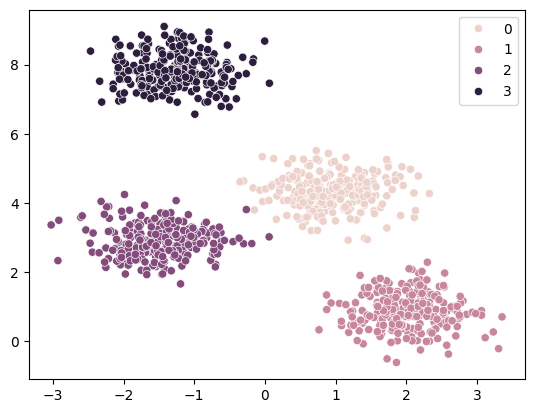

In [ ]:
sns.scatterplot(x = X1[:,0], y = X1[:,1], hue = y1) # Graficar dispersión blobs gaussianos 1
plt.show()

**Segundo conjunto de datos**

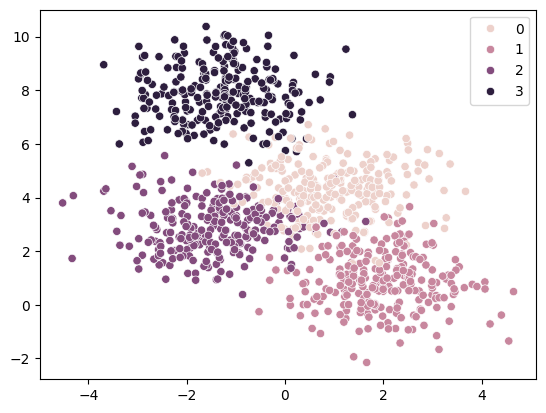

In [ ]:
sns.scatterplot(x = X2[:,0], y = X2[:,1], hue = y2) # Graficar dispersión blobs gaussianos 2
plt.show()

**Tercer conjunto de datos**

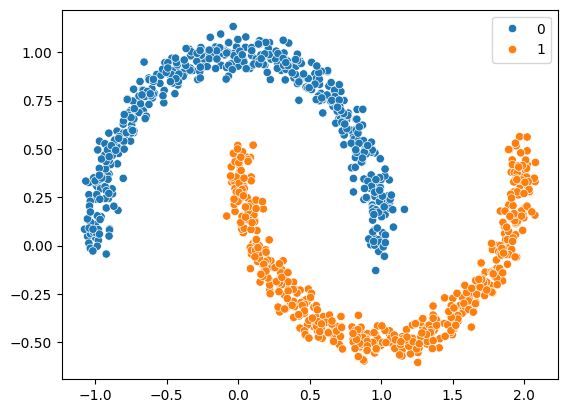

In [ ]:
sns.scatterplot(x = X3[:,0], y = X3[:,1], hue = y3)
plt.show()

#### **K-means** en Scikit-Learn

Scikit-Learn tiene una implementación del método que se identifica con clase llamada **KMeans**. Para más información [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

A continuación vamos a definir tres modelos para los distintos conjuntos de datos.
Detallaremos el modelo del primer conjunto de datos, que se puede replicar metodológicamente en los otros conjuntos de datos.


In [ ]:
from sklearn.cluster import KMeans # Importar librería

In [ ]:
# Crear modelo. Objeto kmeans
kmeans_1 = KMeans(n_clusters=2, random_state=0)
display(kmeans_1)

# Entrenar modelo sobre los datos
kmeans_1.fit(X1)

# Identificar etiquetas
etiquetas_1 = kmeans_1.labels_
print("Etiquetas:", np.unique(etiquetas_1))
#print("Forma de Objeto etiqueta:",etiquetas_1.shape)

# Identificar centroide
centros_1 = kmeans_1.cluster_centers_
print("Centroides:\n",centros_1)


KMeans(n_clusters=2, random_state=0)

Etiquetas: [0 1]
Centroides:
 [[ 0.48998192  2.69257904]
 [-1.27283855  7.84651464]]



* n_clusters=3: indica que vamos a generar 2 clústeres. Indicar random_state=0 permite fijar la semilla de número aleatorio, lo que garantiza obtener los mismos resultados cada vez que lo ejecutemos.

* fit(X): entrena el modelo con tus datos.

* labels_: te dice a qué clúster pertenece cada observación.

* cluster_centers_: te da la ubicación de los centroides.

Grafiquemos los resultados para para el primer conjunto de datos. **¿Les parece que la separación fue adecuada?**

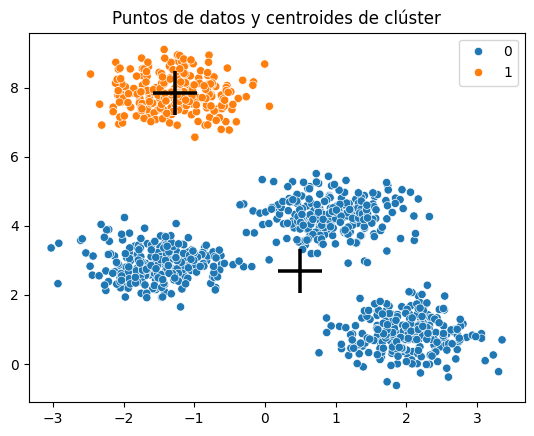

In [ ]:
sns.scatterplot(x=X1[:, 0], y=X1[:, -1], hue = etiquetas_1) # Noten que aca pasamos las etiquetas del CLUSTERING (no las originales)
sns.scatterplot(x=centros_1[:, 0], y=centros_1[:, 1],color='black', marker="+", s=1000)
plt.title('Puntos de datos y centroides de clúster')
plt.show()

Aplicando a los otros conjuntos de datos

In [ ]:
# Crear modelos
kmeans_2 = KMeans(4, random_state=0)
kmeans_3 = KMeans(2, random_state=0)

# Entrenar modelos
kmeans_2.fit(X2)
kmeans_3.fit(X3)

# Etiquetas y Centroides
etiquetas_2 = kmeans_2.labels_
centros_2 = kmeans_2.cluster_centers_
etiquetas_3 = kmeans_3.labels_
centros_3 = kmeans_3.cluster_centers_



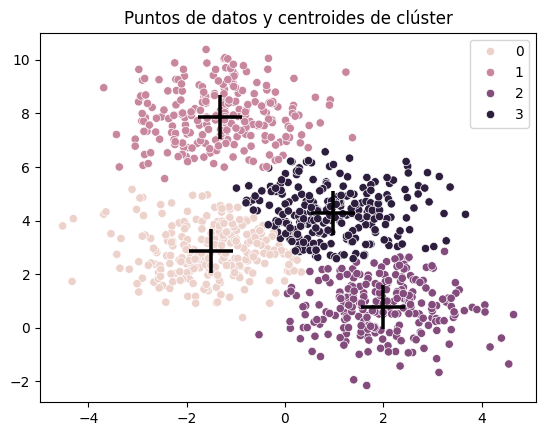

In [ ]:
# Visualizar para segundo conjunto de datos
sns.scatterplot(x=X2[:, 0],y=X2[:, -1], hue = etiquetas_2)
sns.scatterplot(x=centros_2[:, 0],y=centros_2[:, 1],color='black', marker="+", s=1000)
plt.title('Puntos de datos y centroides de clúster')
plt.show()

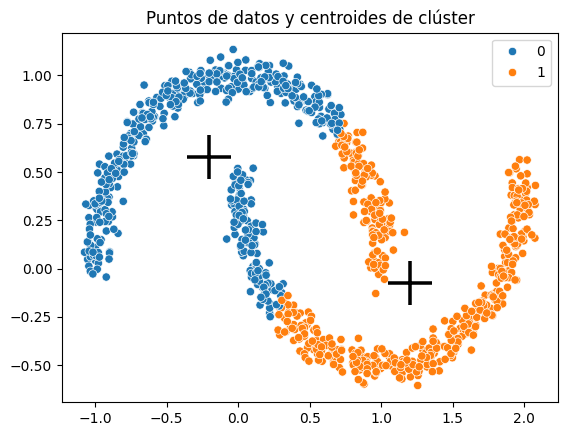

In [ ]:
# Visualizar para tercer conjunto de datos

sns.scatterplot(x=X3[:, 0], y=X3[:, -1], hue = etiquetas_3)
sns.scatterplot(x=centros_3[:, 0], y=centros_3[:, 1],color='black', marker="+", s=1000)
plt.title('Puntos de datos y centroides de clúster')
plt.show()

**¿Qué pasa si no elegimos correctamente el número de clusters?**

### 🥇Encontrar el número óptimo de clústeres

### Inercia

También conocida como suma de cuadrados dentro del cluster (WCSS por sus siglas en inglés, "within-cluster sum of squares"), mide la cantidad de dispersión (o varianza) de los puntos dentro de cada cluster. Específicamente, la inercia es la _suma de las distancias al cuadrado de cada punto a su centroide más cercano_.

Vamos a evaluar las particiones que realizamos mediante KMeans usando la **inercia**. La idea es que **al variar el número de clúster K en el modelo, el valor de la distancia media de los datos al centroide más cercano va a variar**. Queremos **graficar esa curva para elegir el número de particiones óptimos con el metodo del codo**.




La inercia tiene varias propiedades importantes:

* **Valor mínimo**: La inercia siempre es un valor no negativo.
* **Cero**: La inercia es cero cuando cada punto está exactamente en su centroide, lo cual es un caso ideal pero raramente alcanzable en la práctica.
* **Disminuye a medida que aumenta el número de clusters**: Si aumentas el número de clusters (K) al total de puntos (n) en tu conjunto de datos, cada punto se convertirá en su propio centroide y la inercia será cero.

Uno de los atributos de kmeans en sklearn es `inertia_` .Analizando para el primer conjunto de datos y evaluando para diferentes valors de K podemos identificar la inercia asociada a cada k.

In [ ]:
K_list = np.arange(2,13) # Lista de valores de K

In [ ]:
lista_inercias = []

for k in K_list:
    km = KMeans(n_clusters=k, random_state = 0) # Crear modelo para k específico
    km = km.fit(X1) # Entrenar modelo
    inercia = km.inertia_ # inercia
    lista_inercias.append(inercia) # Guardar inercia asociada al k específico

Graficando la inercia para k : 2 - 12

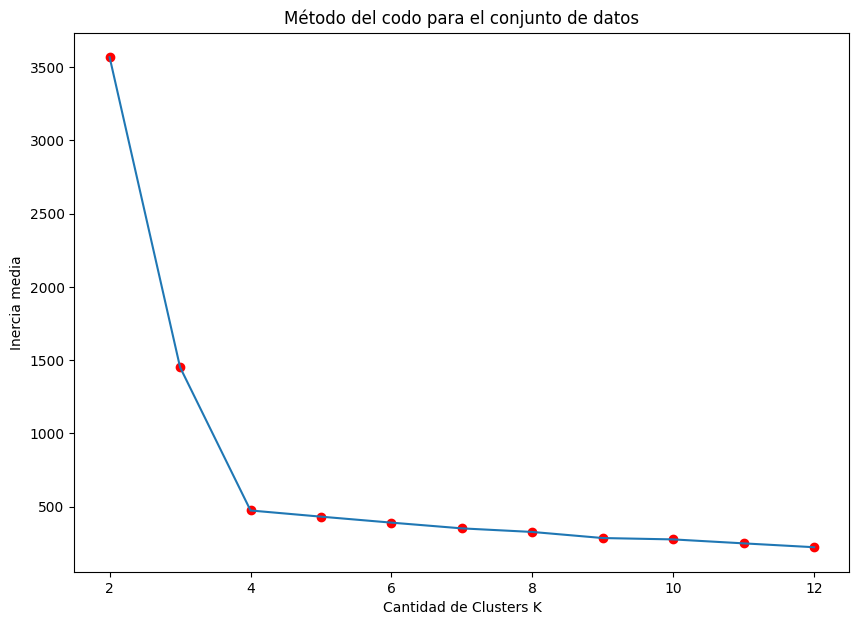

In [ ]:
plt.figure(figsize = (10,7))
plt.plot(K_list,lista_inercias)
plt.scatter(K_list,lista_inercias,c='r')
plt.xlabel('Cantidad de Clusters K')
plt.ylabel('Inercia media')
plt.title('Método del codo para el conjunto de datos')

plt.show()

¿Cómo se usa el método del codo?

* Se ejecuta K-means para varios valores de k (por ejemplo, de 2 a 12).
* Se grafica k en el eje x, e inercia en el eje y.
* Se busca el "codo" de la curva: el punto donde la inercia empieza a disminuir más lentamente. Ese suele ser el k óptimo.



¿Pueden ver el "codo"?

De esta forma para este problema **el número óptimo de clusteres sería 4.**


### Silhouette

Vamos a evaluar las particiones que realizamos mediante el valor de ***silhouette***. La *silhouette* se calcula en base a la diferencia ponderada entre el punto y los 2 centroides más cercanos. Asume valores entre -1 y 1.

Vamos a calcular el valor de silhouette promedio para distintos valores de K. La manera de hacerlo es igual a la que usamos para calcular los valores de inercia, vamos a recorrer con un for los distintos modelos e ir agregando a una lista los valores. Esta vez, en lugar de calcular la inercia, vamos a calcular el valor de **silhouette usando la función** `silhouette_score` de scikit-learn.

In [ ]:
from sklearn.metrics import silhouette_score

Ahora, de la misma forma que hicimos con el método del codo, calcular el silhouette score para cada valor de k (entre 2 y 12) para el dataset X1 y plotear.


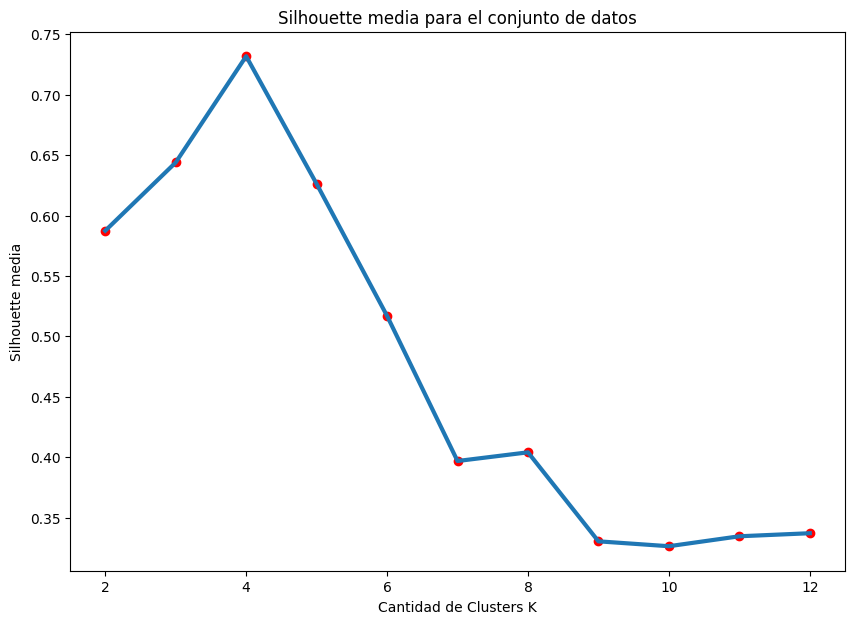

In [ ]:
sil_list = []

for k in K_list:
    km = KMeans(n_clusters=k, random_state = 0) #  # Crear modelo para k específico
    km = km.fit(X1)

    etiquetas = km.labels_

    valor_medio_sil = silhouette_score(X1, etiquetas)
    sil_list.append(valor_medio_sil) # Guardar el valor de silhouette

plt.figure(figsize = (10,7))
plt.plot(K_list, sil_list, lw=3)
plt.scatter(K_list, sil_list, c='r')
plt.xlabel('Cantidad de Clusters K')
plt.ylabel('Silhouette media')
plt.title('Silhouette media para el conjunto de datos')

plt.show()

Para n_clusters = 2 El puntaje de silueta promedio es : 0.5874173200871528
Para n_clusters = 3 El puntaje de silueta promedio es : 0.6438724743974136
Para n_clusters = 4 El puntaje de silueta promedio es : 0.73176520081899
Para n_clusters = 5 El puntaje de silueta promedio es : 0.6261517198522742
Para n_clusters = 6 El puntaje de silueta promedio es : 0.5169477274678268
Para n_clusters = 7 El puntaje de silueta promedio es : 0.3969027886537873
Para n_clusters = 8 El puntaje de silueta promedio es : 0.40408486405447985
Para n_clusters = 9 El puntaje de silueta promedio es : 0.3304541788421752
Para n_clusters = 10 El puntaje de silueta promedio es : 0.32640802094199567
Para n_clusters = 11 El puntaje de silueta promedio es : 0.3346350815735067
Para n_clusters = 12 El puntaje de silueta promedio es : 0.33715957720334916


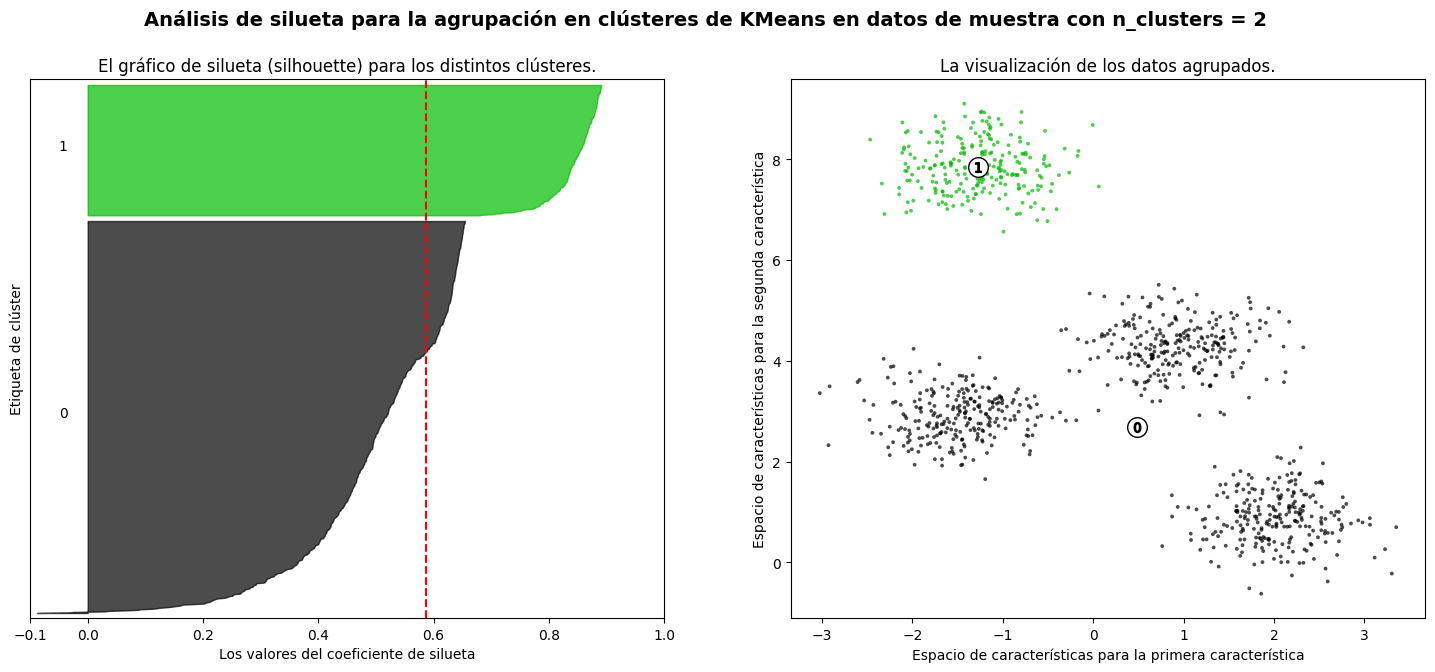

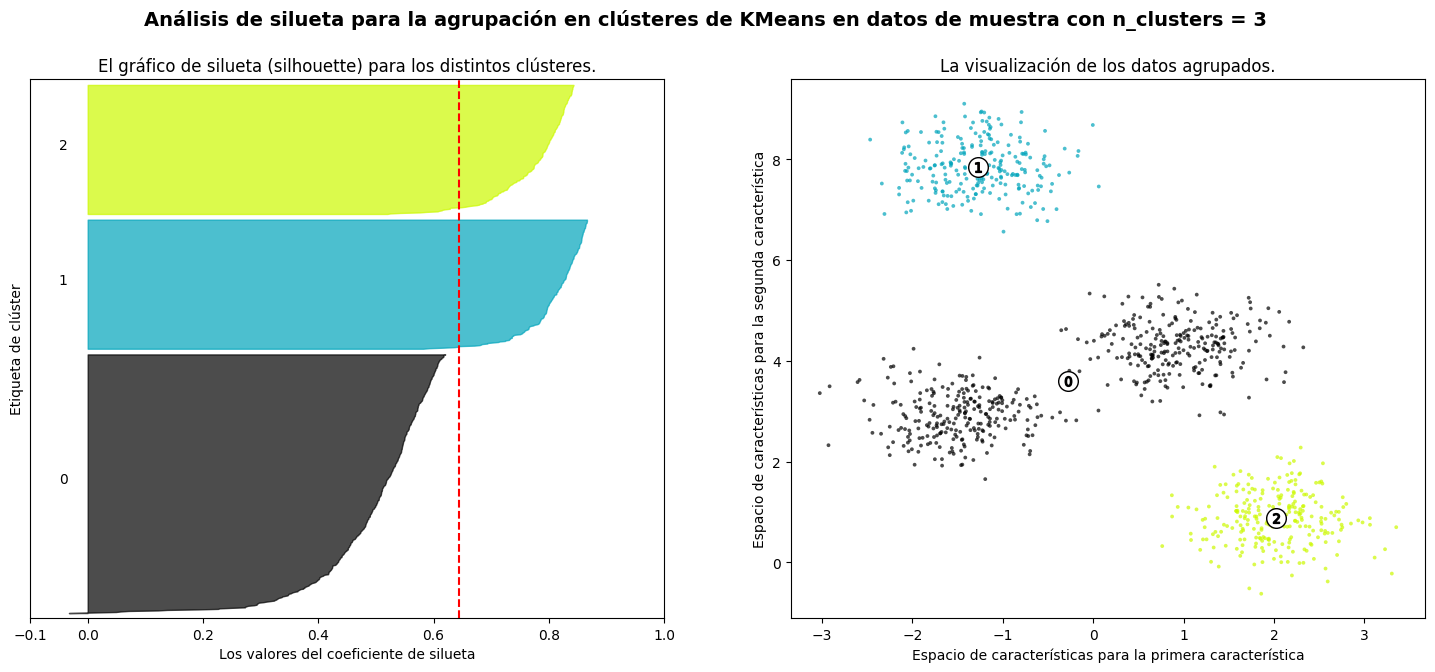

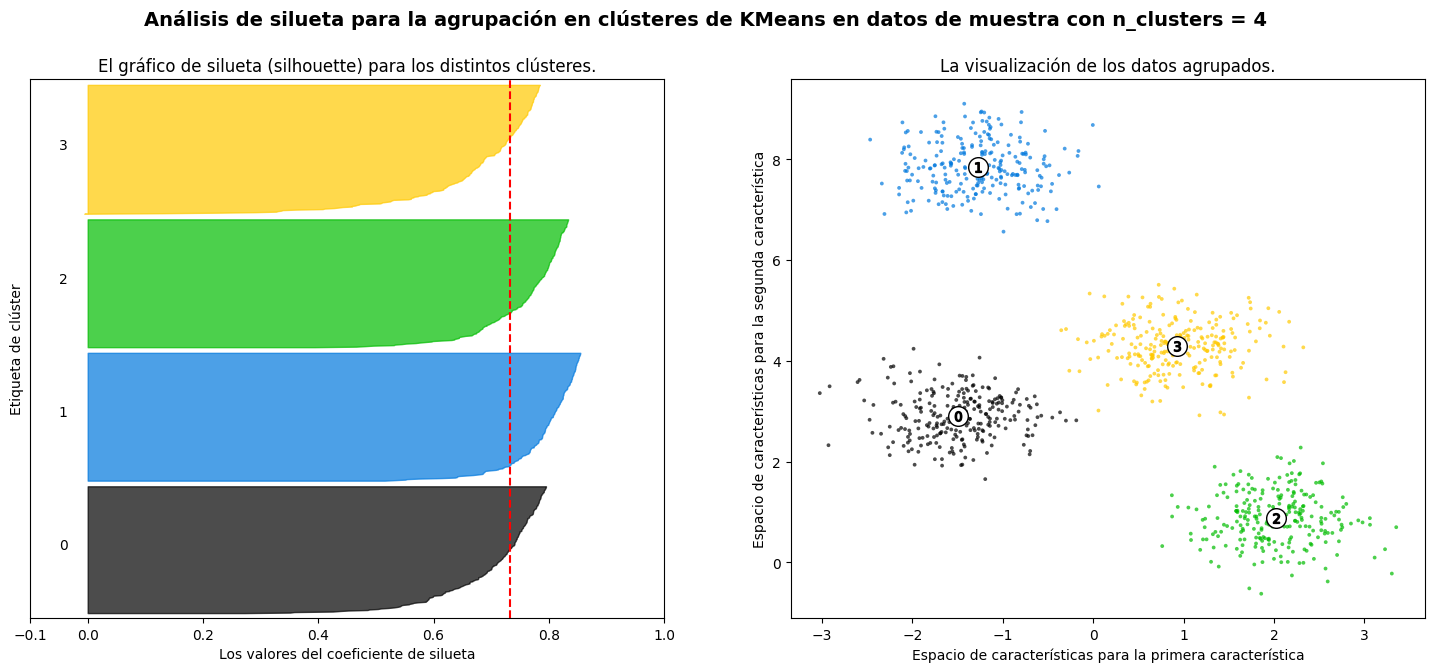

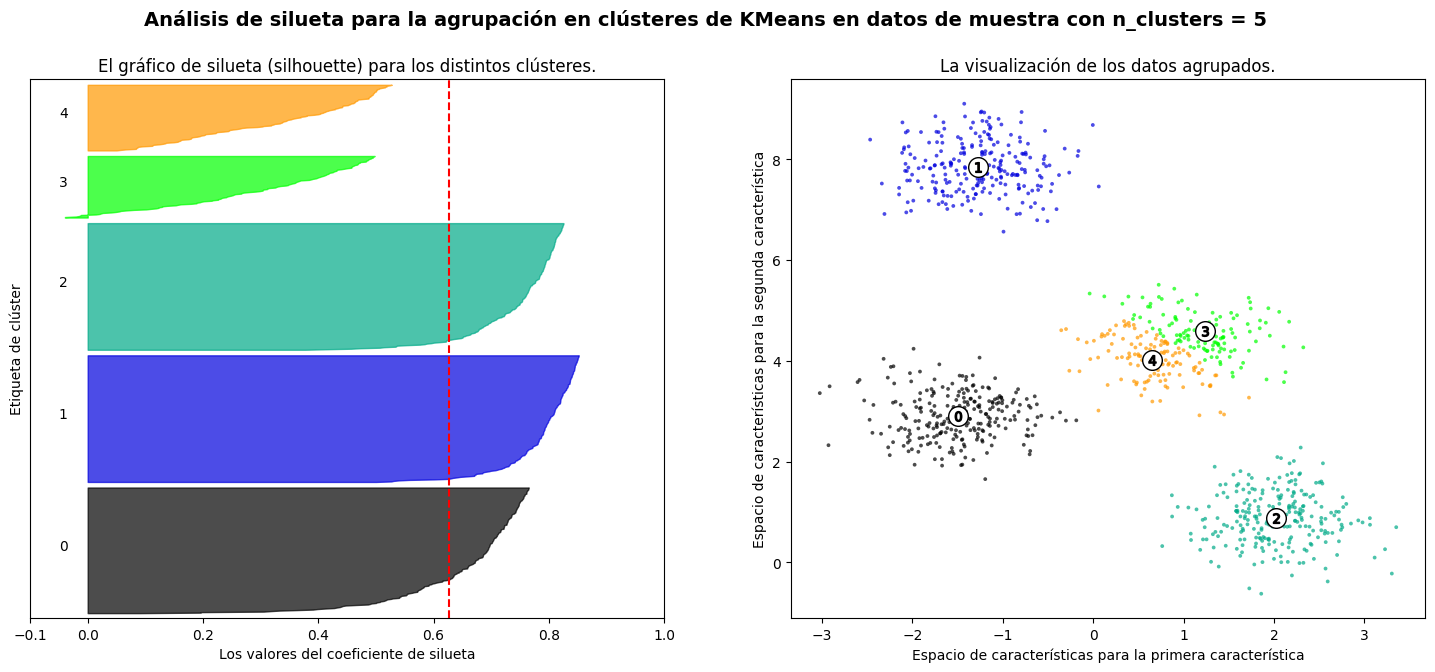

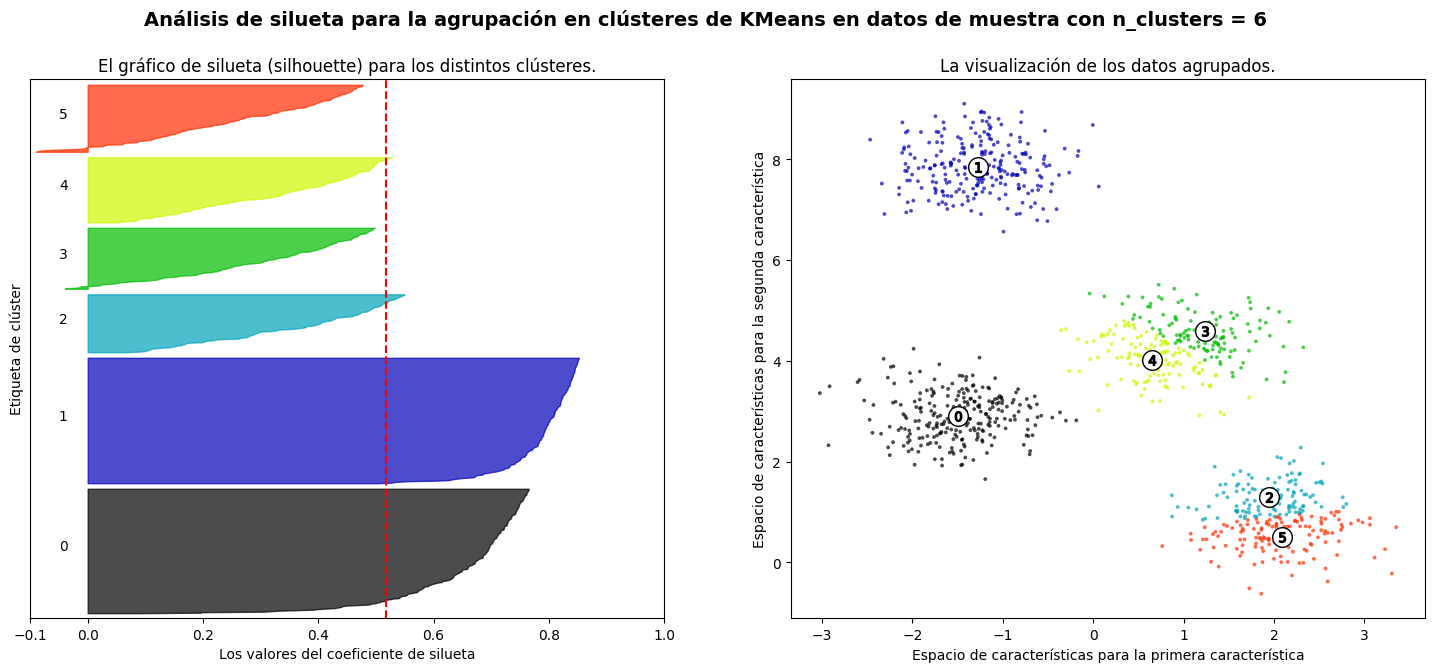

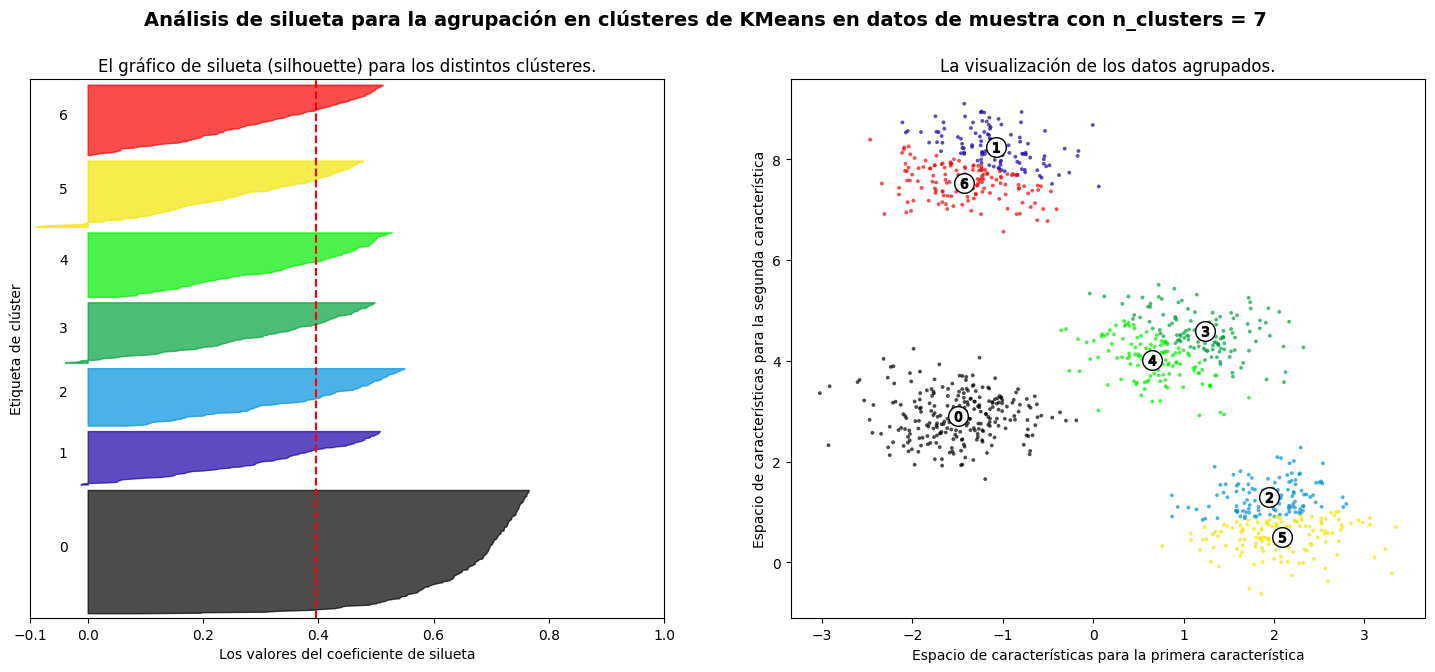

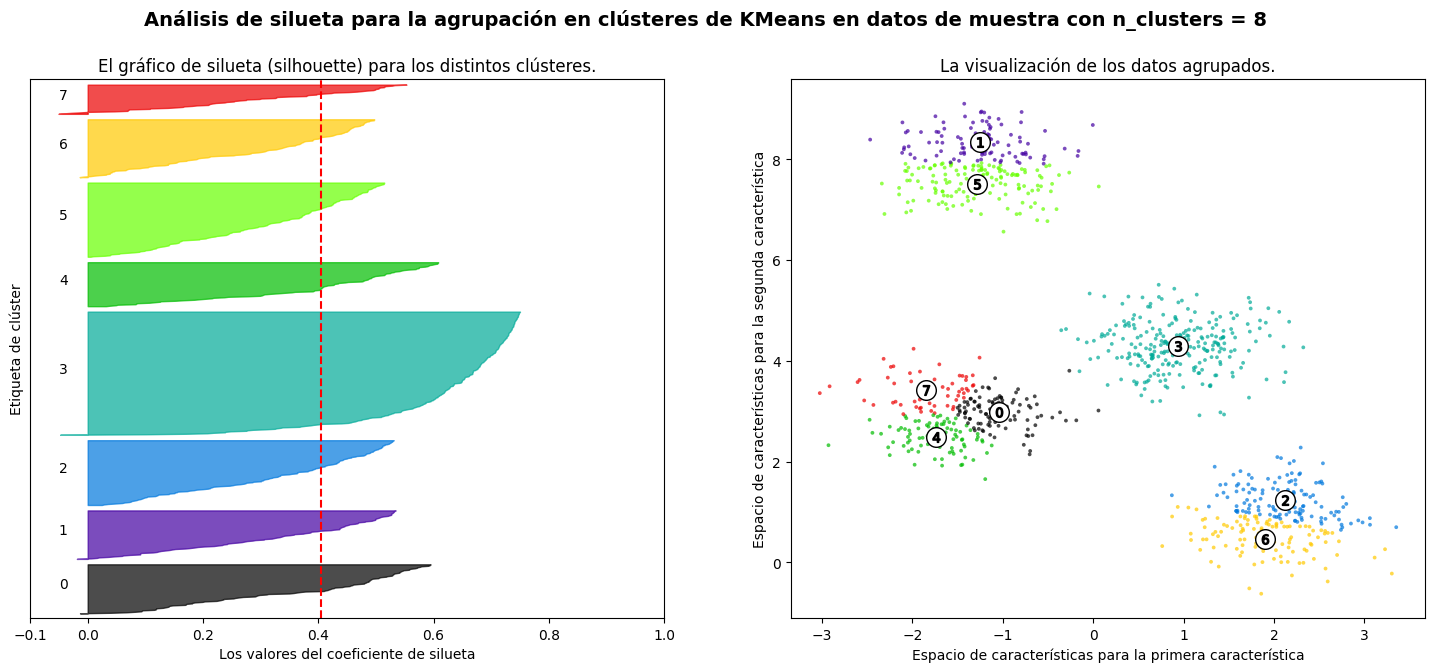

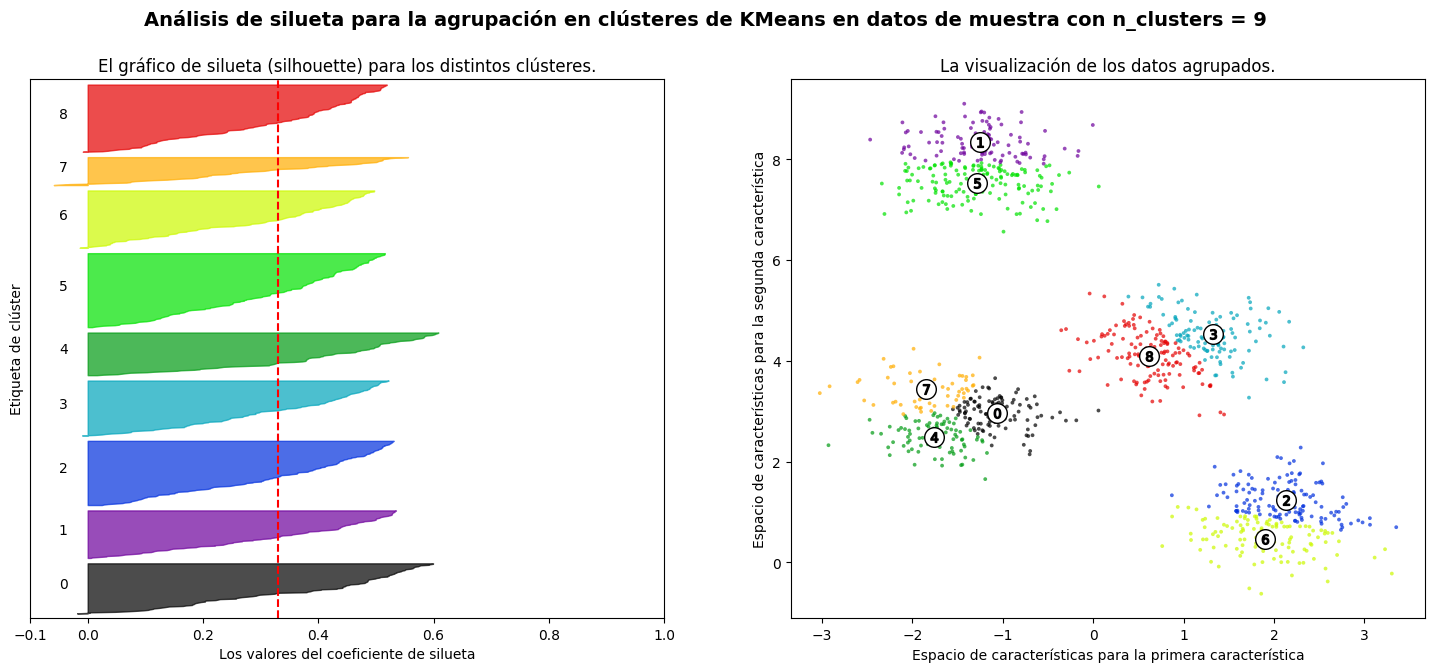

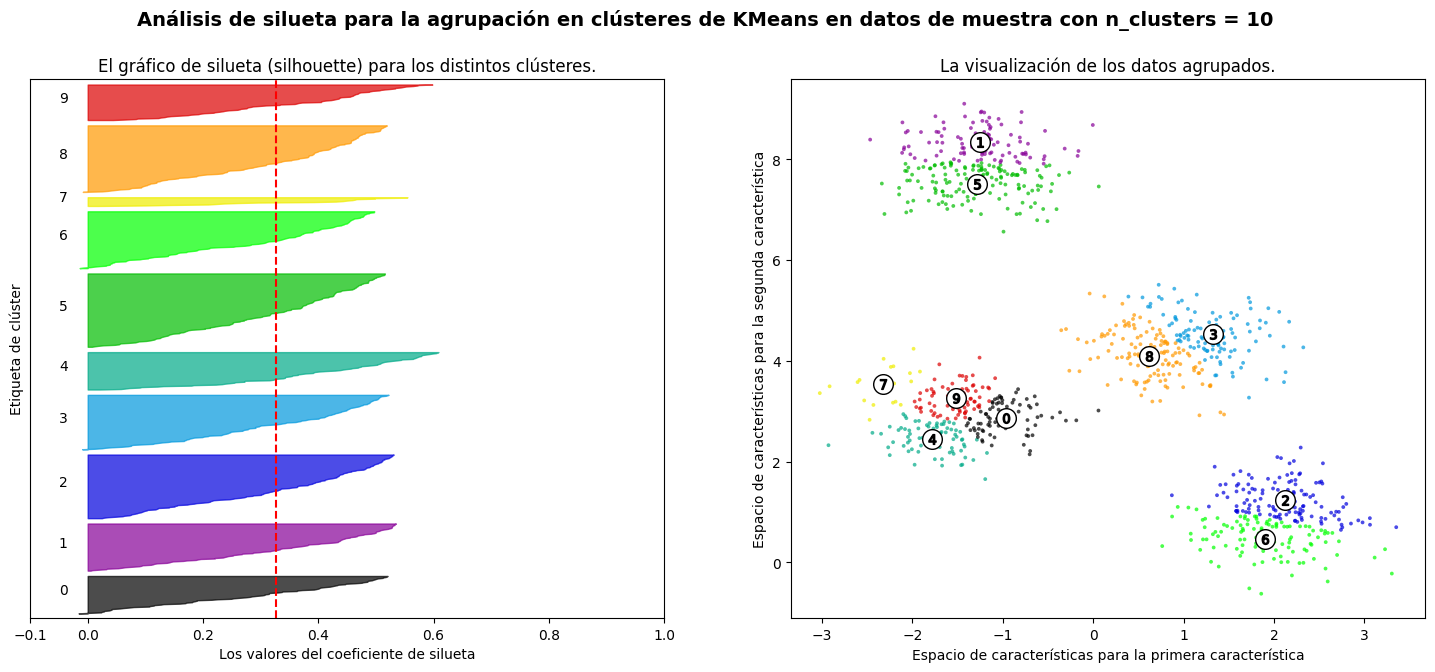

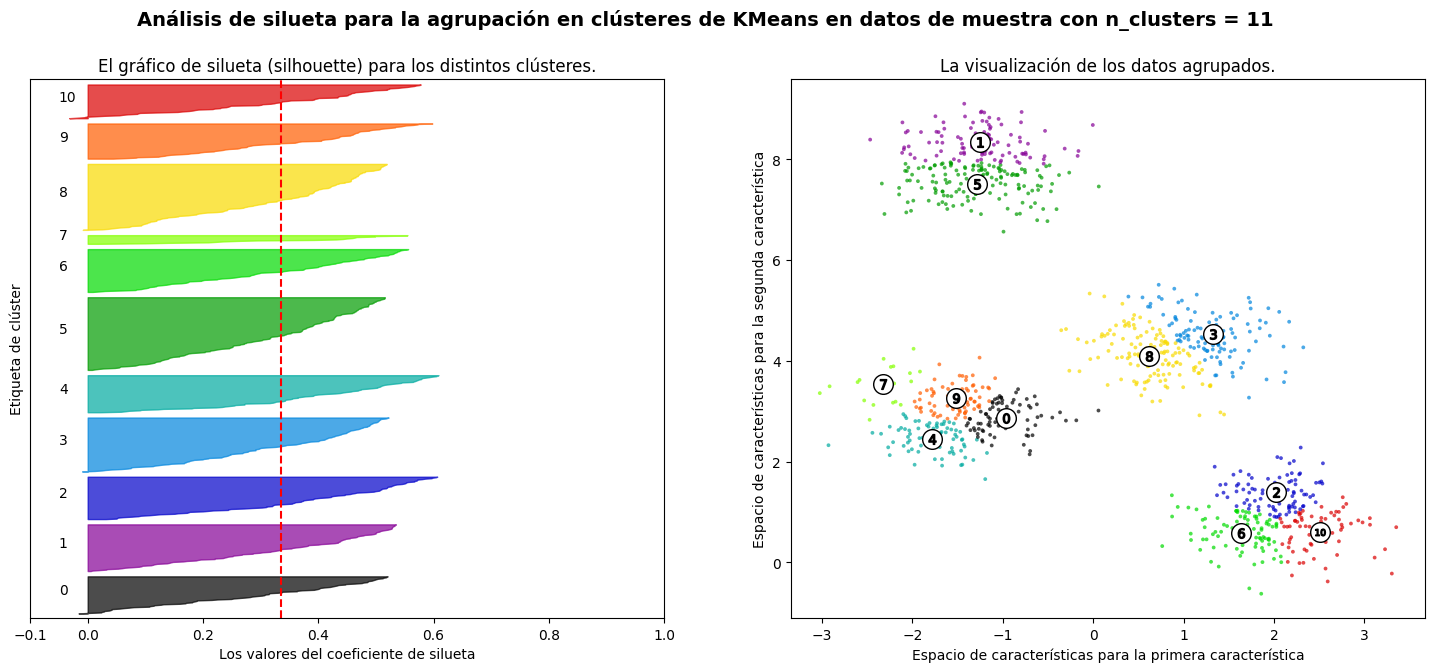

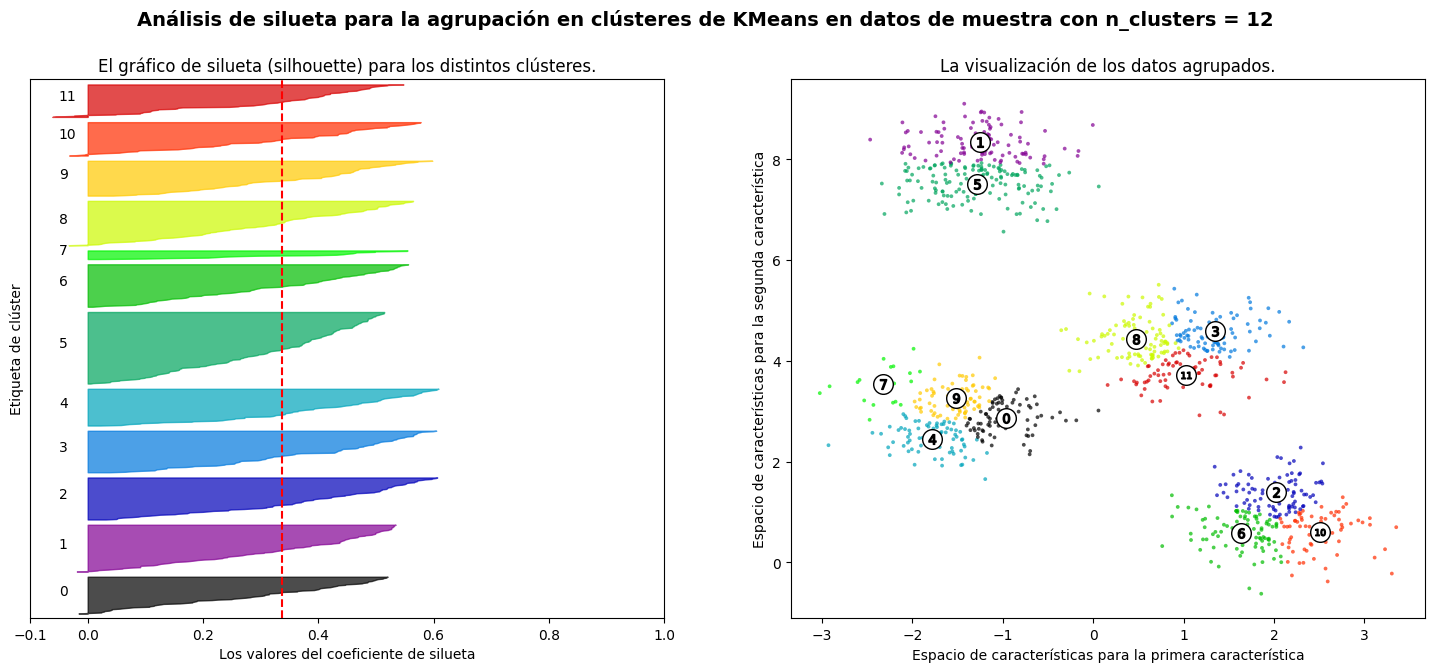

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Primer conjunto de datos
X = X1
Y = y1

# Lista de k clusters
range_n_clusters = K_list

for n_clusters in range_n_clusters:
    # Crear una subparcela con 1 fila y 2 columnas
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)


    # La primera subtrama es la gráfica de silueta.
    # El coeficiente de silueta puede variar entre -1 y 1, pero en este ejemplo todos los valores están dentro de [-0.1, 1].
    ax1.set_xlim([-0.1, 1])

    # El valor (n_clusters+1)*10 se utiliza para insertar un espacio en blanco entre los gráficos de silueta de los grupos individuales, para delimitarlos claramente.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])


    # Inicialice el clusterizador con el valor n_clusters y un generador aleatorio.
    # Semilla de 10 para reproducibilidad.
    clusterer = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = clusterer.fit_predict(X)

    # La puntuación de silueta proporciona el valor promedio de todas las muestras.
    # Esto ofrece una perspectiva de la densidad y la separación de los grupos formados.

    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "Para n_clusters =",
        n_clusters,
        "El puntaje de silueta promedio es :",
        silhouette_avg,
    )

    # Calcular las puntuaciones de silueta para cada muestra
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Agregar las puntuaciones de silueta de las muestras pertenecientes al grupo i y ordenarlas
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        # Etiqueta las parcelas de silueta con sus números de grupo en el medio
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        # Calcular el nuevo y_lower para el siguiente gráfico
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("El gráfico de silueta (silhouette) para los distintos clústeres.")
    ax1.set_xlabel("Los valores del coeficiente de silueta")
    ax1.set_ylabel("Etiqueta de clúster")
    # La línea vertical para la puntuación de silueta promedio de todos los valores
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2da gráfica que muestra los grupos reales formados
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Etiquetado de los clústeres
    centers = clusterer.cluster_centers_

    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("La visualización de los datos agrupados.")
    ax2.set_xlabel("Espacio de características para la primera característica")
    ax2.set_ylabel("Espacio de características para la segunda característica")

    plt.suptitle(
        "Análisis de silueta para la agrupación en clústeres de KMeans en datos de muestra con n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [ ]:
print("El valor óptimo de clusteres por medio del criterio de silhouette es", max(sil_list))

El valor óptimo de clusteres por medio del criterio de silhouette es 0.73176520081899


Para interpretar la gráfica:
* Cada banda horizontal representa un cluster.

* La anchura de cada banda muestra cuán bien definidas están las instancias dentro de ese cluster.

* Una silueta más ancha y a la derecha (cerca de 1) indica que las instancias están bien agrupadas.

* Siluetas negativas o muy pequeñas indican que algunos puntos podrían estar mal asignados.

¿Cómo se elige k con este método?

* Ejecutar el clustering para varios valores de k.
* Calcular el promedio del coeficiente de silueta para cada uno.
* Elegir el k que tenga el mayor valor promedio de silueta.


📝 Ejercicio
* Para el  primer conjunto de datos usa KMeans con k=5.

* Calculá la gráfica de silueta usando silhouette_samples.

* Usá matplotlib para visualizar la silueta por clúster.

* Analizá el agrupamiento: ¿hay clústeres mal asignados?

**Haz doble click para ver la respuesta**
<!--
#Observando la gráfica el cluster 4 y cluster 0 no superan el valor promedio de silhouette.
#Tal que el clúster 0 presentan valores negativos indican que indica que algunos puntos podrían estar mal asignados.
#Podriamos decir que hay clusteres mal asignados.

from sklearn.metrics import silhouette_samples
import numpy as np

X = X1
Y = y1
k = 5

# Aplicar KMeans con k=3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# Calcular silueta para cada punto
sil_values = silhouette_samples(X, labels)

# Preparar visualización
plt.figure(figsize=(8, 6))
y_lower = 10
for i in range(k):
    ith_cluster_sil_values = sil_values[labels == i]
    ith_cluster_sil_values.sort()
    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}')
    y_lower = y_upper + 10  # espacio entre clusters

plt.axvline(x=silhouette_score(X, labels), color="red", linestyle="--", label="Silhouette promedio")
plt.title("Gráfico de Silueta para k=5")
plt.xlabel("Valor del coeficiente de silueta")
plt.ylabel("Muestras")
plt.legend()
plt.show()
print("silhouette promedio:",silhouette_score(X, labels))
-->

## 🎯 La maldición de la dimensión

### 🥇Reducción de la dimensionalidad. Análisis de Componentes Principales (Principal component analysis , PCA)

Técnica para la extracción de características linealmente independientes. Teniendo en cuenta la siguiente figura, suponga que existe un conjunto de datos con n muestras cada uno con  p variables, es decir, el espacio muestral tiene p dimensiones. PCA permite encontrar un número de factores subyacentes z  que explican aproximadamente lo mismo que las p variables originales. Cada una de estas  z son nuevas variables y reciben el nombre de componente principal.


El siguiente código aplica el PCA para reducir la dimensionalidad del conjunto de datos a dos dimensiones:

In [ ]:
import numpy as np
from sklearn.decomposition import PCA # importar Libreria

# Crear datos
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
print("Datos:\n",X)

# Crear Objeto PCA
pca = PCA(n_components=2) # Crear dos componentes

# Entrenar y transformar
componentes_2d = pca.fit_transform(X)
print("Dos componentes principales:\n",componentes_2d)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Valores singulares:",pca.singular_values_)


Datos:
 [[-1 -1]
 [-2 -1]
 [-3 -2]
 [ 1  1]
 [ 2  1]
 [ 3  2]]
Dos componentes principales:
 [[-1.38340578 -0.2935787 ]
 [-2.22189802  0.25133484]
 [-3.6053038  -0.04224385]
 [ 1.38340578  0.2935787 ]
 [ 2.22189802 -0.25133484]
 [ 3.6053038   0.04224385]]
Varianza explicada: [0.99244289 0.00755711]
Valores singulares: [6.30061232 0.54980396]


En el código se observa el argumento n_components=2 , PCA transformará los datos para que se representen con solo 2 componentes principales, elegidos de forma que expliquen la mayor cantidad de varianza posible. Si no se especifica n_components == min(n_muestras, p_características). Para tener en cuenta:
* explained_variance_ratio_: proporción de varianza explicada por cada componente.
* fit_transform(X): transforma los datos originales a su nueva representación reducida.

Veamos mejor el caso de uso, para comprender mejor e interpretar los resultados. Vamos a relacionar k-means y PCA.



## Caso de uso

### Conjunto de datos


**Contexto**

Imaginemos que un fabricante de automóviles ha desarrollado prototipos de un nuevo vehículo. Antes de introducir el nuevo modelo en su gama, el fabricante quiere determinar qué vehículos existentes en el mercado se parecen más a los prototipos, es decir, ¿cómo se pueden agrupar los vehículos?, ¿qué grupo es el más similar con el modelo?¿contra qué modelos competirán?.

Para descargar los datos, usaremos !wget desde IBM Object Storage.

**Objetivo del modelo**

Identificar grupos de vehículos más distintivos para ayudar a los fabricantes a tomar decisiones sobre nuevos modelos de forma sencilla.


**Diccionario de datos**

El conjunto de datos corresponde a autos. Las  características incluyen:
* price: precio en miles
* engine_s: tamaño del motor
* horsepow: caballos de fuerza
* wheelbas: distancia entre ejes
* width: ancho
* length: largo
* curb_wgt: peso en vacío
* fuel_cap: capacidad de combustible
* mpg: eficiencia de combustible

In [ ]:
import pandas as pd # importar librería

In [ ]:
!wget -O cars_clus.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/cars_clus.csv

--2025-07-07 15:09:27--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/cars_clus.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17774 (17K) [text/csv]
Saving to: ‘cars_clus.csv’

cars_clus.csv       100%[===================>]  17.36K  --.-KB/s    in 0s      

2025-07-07 15:09:27 (182 MB/s) - ‘cars_clus.csv’ saved [17774/17774]



In [ ]:
nombre_archivo = 'cars_clus.csv'

#Read csv
autos_df = pd.read_csv(nombre_archivo)
print ("Forma del conjunto de datos: ", autos_df.shape)
display(autos_df.head())
display(autos_df.info())

Forma del conjunto de datos:  (159, 16)


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   manufact   157 non-null    object 
 1   model      159 non-null    object 
 2   sales      159 non-null    object 
 3   resale     159 non-null    object 
 4   type       159 non-null    object 
 5   price      159 non-null    object 
 6   engine_s   159 non-null    object 
 7   horsepow   159 non-null    object 
 8   wheelbas   159 non-null    object 
 9   width      159 non-null    object 
 10  length     159 non-null    object 
 11  curb_wgt   159 non-null    object 
 12  fuel_cap   159 non-null    object 
 13  mpg        159 non-null    object 
 14  lnsales    159 non-null    object 
 15  partition  159 non-null    float64
dtypes: float64(1), object(15)
memory usage: 20.0+ KB


None

Se observa que las características son de tipo cadena, cuando deberían ser numéricas

Observando estadísticas descriptiva

In [ ]:
autos_df.describe(include='all'). T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
manufact,157,30,Ford,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,159,158,Neon,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,159,158,$null$,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resale,159,118,$null$,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,159,3,0.000,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,159,154,21.500,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_s,159,32,2.000,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horsepow,159,69,150.000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheelbas,159,90,112.200,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
width,159,80,74.400,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Transformamos los datos a numéricos según corresponde

In [ ]:
print ("Forma del conjunto de datos antes de la limpieza: ", autos_df.size)
autos_df[[ 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']] = autos_df[['sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']].apply(pd.to_numeric, errors='coerce')
autos_df = autos_df.dropna()
autos_df = autos_df.reset_index(drop=True)
print ("Forma del conjunto de datos despues de la limpieza: ", autos_df.size)



Forma del conjunto de datos antes de la limpieza:  2544
Forma del conjunto de datos despues de la limpieza:  1872


In [ ]:
autos_df.describe(include='all'). T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
manufact,117,26,Ford,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,117,116,Neon,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,117.0,NaN,NaN,NaN,59.112316,75.058933,0.11,16.767,32.299,76.029,540.561
resale,117.0,NaN,NaN,NaN,18.031538,11.605632,5.16,11.24,14.01,19.875,67.55
type,117.0,NaN,NaN,NaN,0.247863,0.433629,0.0,0.0,0.0,0.0,1.0
price,117.0,NaN,NaN,NaN,25.969487,14.149699,9.235,16.98,21.665,29.465,82.6
engine_s,117.0,NaN,NaN,NaN,3.048718,1.055169,1.0,2.2,3.0,3.8,8.0
horsepow,117.0,NaN,NaN,NaN,181.282051,58.591786,55.0,140.0,175.0,210.0,450.0
wheelbas,117.0,NaN,NaN,NaN,107.326496,8.050588,92.6,102.4,107.0,111.6,138.7
width,117.0,NaN,NaN,NaN,71.189744,3.530151,62.6,68.5,70.4,73.6,79.3


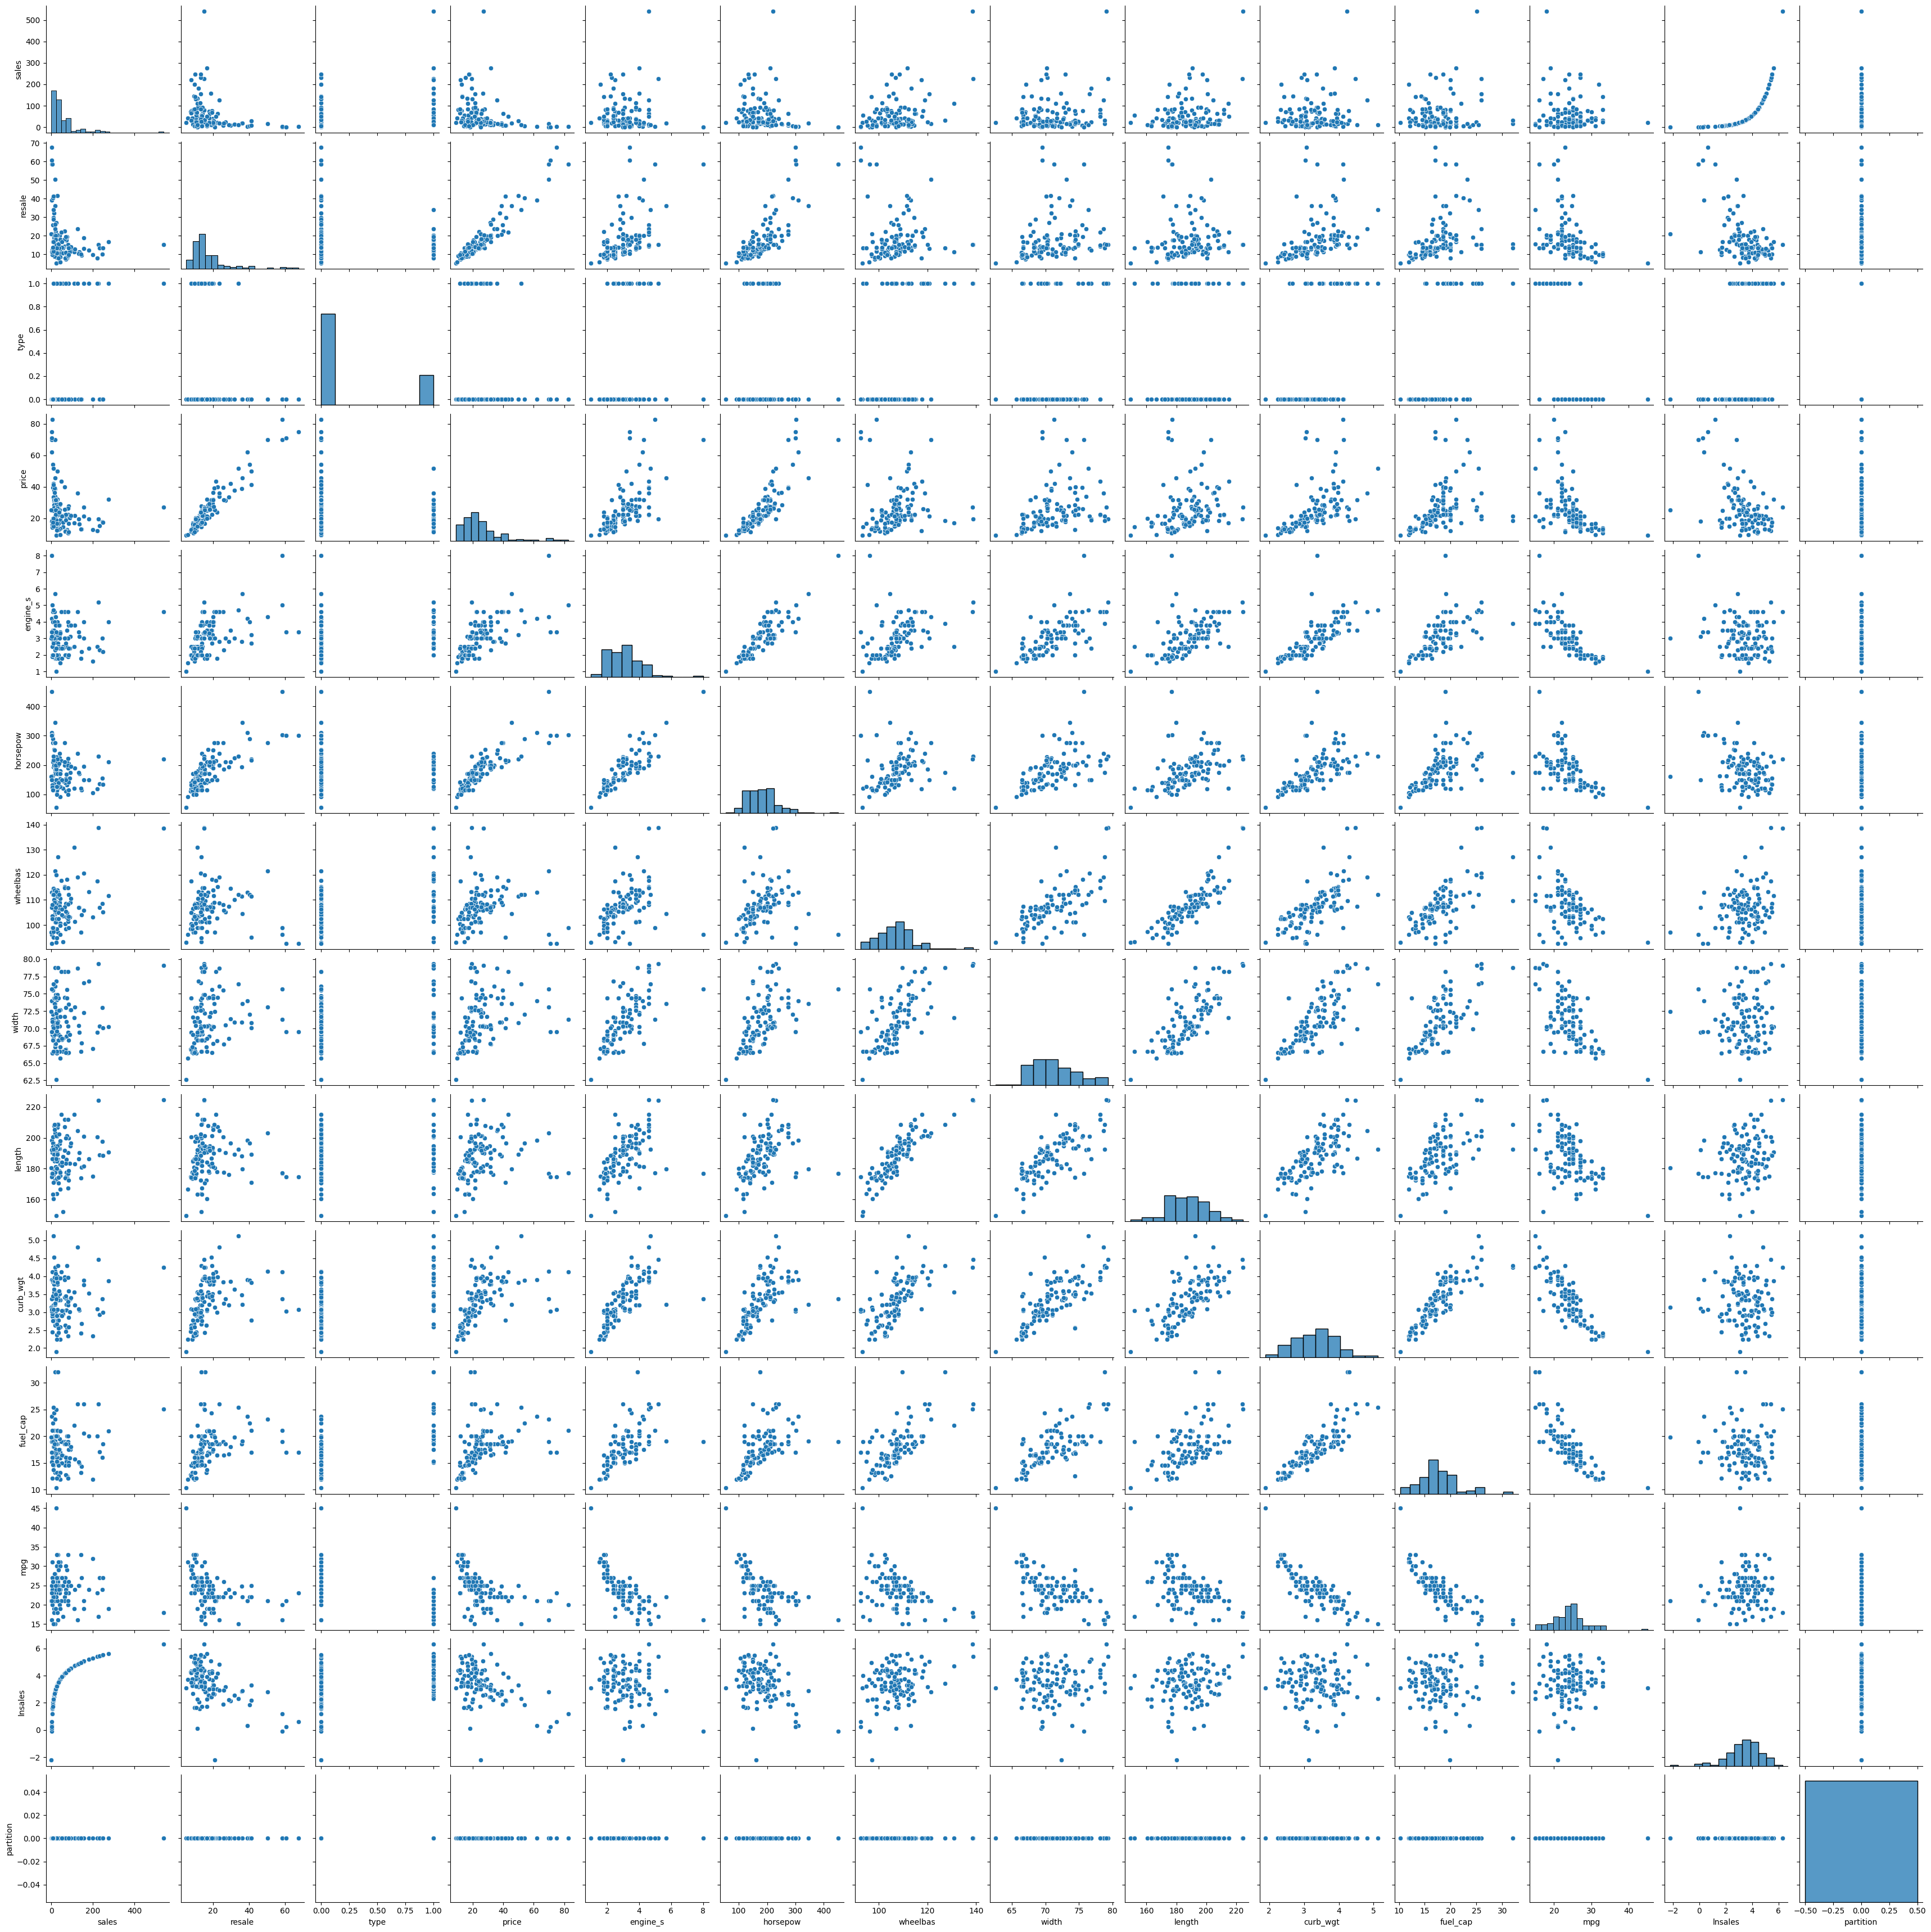

In [ ]:
numeric_df = autos_df.select_dtypes(include='number')
sns.pairplot(numeric_df)

In [ ]:
autos_df.columns

Index(['manufact', 'model', 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales', 'partition'],
      dtype='object')

In [ ]:
# Seleccionar características
selec_df = autos_df[['engine_s', 'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg']]
selec_df.head(2)

,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg
0,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0
1,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0


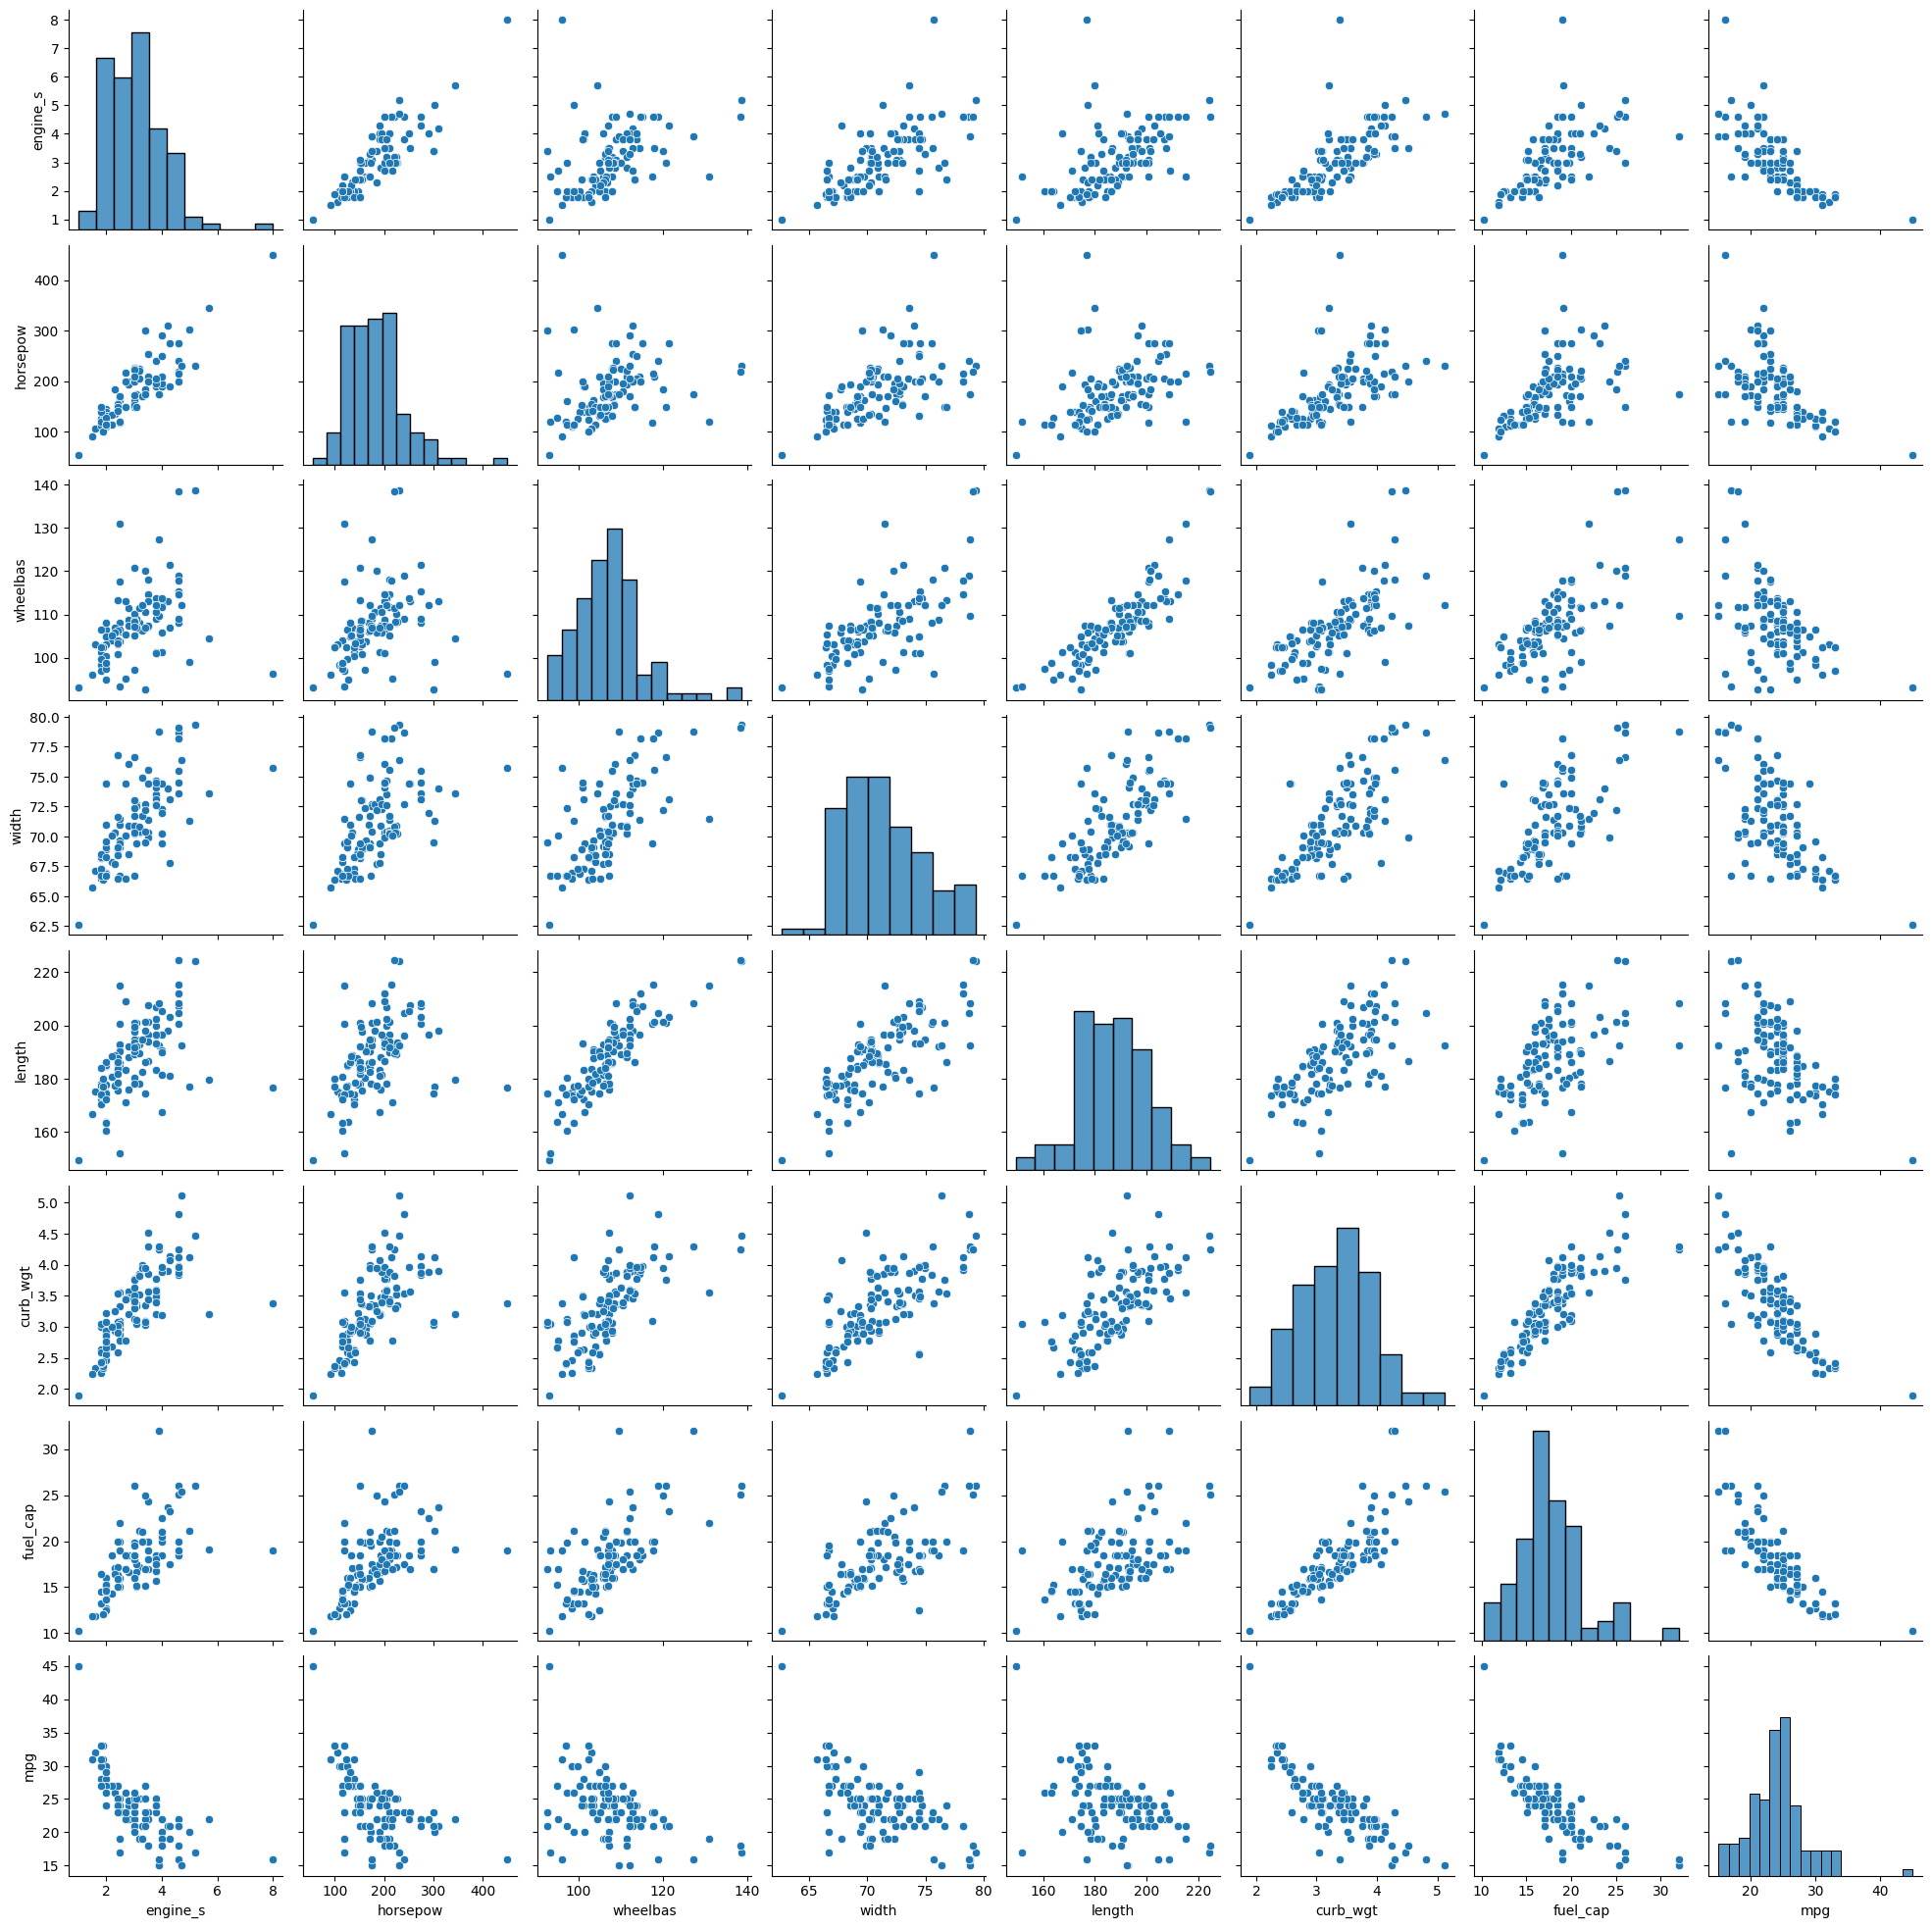

In [ ]:
sns.pairplot(selec_df)

### K-medias: para identificar grupos

Tranformamos los datos, escalamos para que las unidades de las variables no afecte el calculo de las distancias

In [ ]:
from sklearn.preprocessing import MinMaxScaler

x = selec_df.values # Seleccionar datos
min_max_scaler = MinMaxScaler() # Crear objeto transformador
feature_mtx = min_max_scaler.fit_transform(x) # Entrenar y transformar
feature_mtx [0:5]

array([[0.11428571, 0.21518987, 0.18655098, 0.28143713, 0.30625832,
        0.2310559 , 0.13364055, 0.43333333],
       [0.31428571, 0.43037975, 0.3362256 , 0.46107784, 0.5792277 ,
        0.50372671, 0.31797235, 0.33333333],
       [0.35714286, 0.39240506, 0.47722343, 0.52694611, 0.62849534,
        0.60714286, 0.35483871, 0.23333333],
       [0.11428571, 0.24050633, 0.21691974, 0.33532934, 0.38082557,
        0.34254658, 0.28110599, 0.4       ],
       [0.25714286, 0.36708861, 0.34924078, 0.80838323, 0.56724368,
        0.5173913 , 0.37788018, 0.23333333]])

Identificamos grupos de automóviles similares mediante k-means

In [ ]:
K_list = np.arange(2,30) # Lista de valores de K
lista_inercias = []
for k in K_list:
    km = KMeans(n_clusters=k, random_state=0) # Crear modelo para k específico
    km = km.fit(feature_mtx) # Entrenar modelo
    inercia = km.inertia_ # inercia
    lista_inercias.append(inercia) # Guardar inercia asociada al k específico

Text(0.5, 1.0, 'Método del codo para el conjunto de datos')

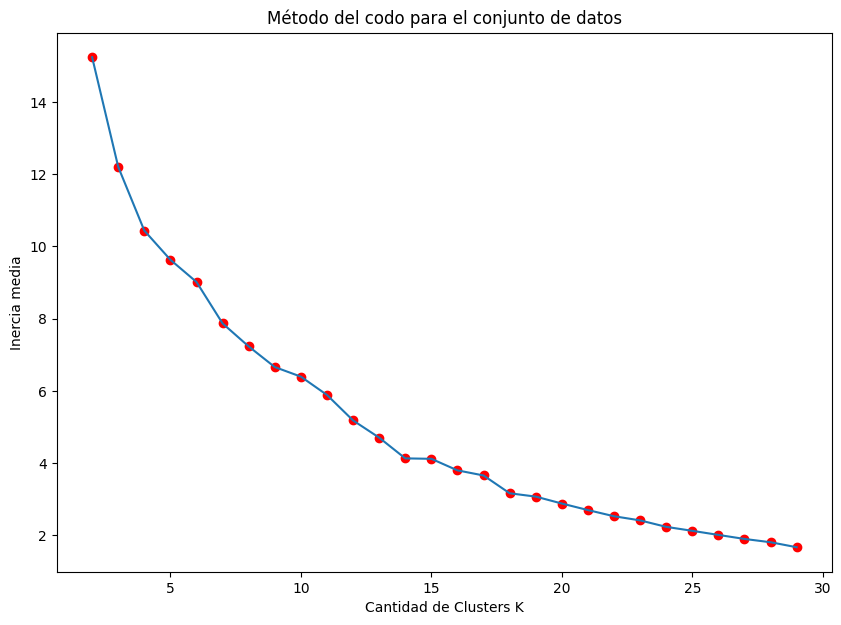

In [ ]:
plt.figure(figsize = (10,7))
plt.plot(K_list,lista_inercias)
plt.scatter(K_list,lista_inercias,c='r')
plt.xlabel('Cantidad de Clusters K')
plt.ylabel('Inercia media')
plt.title('Método del codo para el conjunto de datos')

El codo no es claramente diferenciable, pareciera que k entre 14 o 15 podrían ser óptimo.

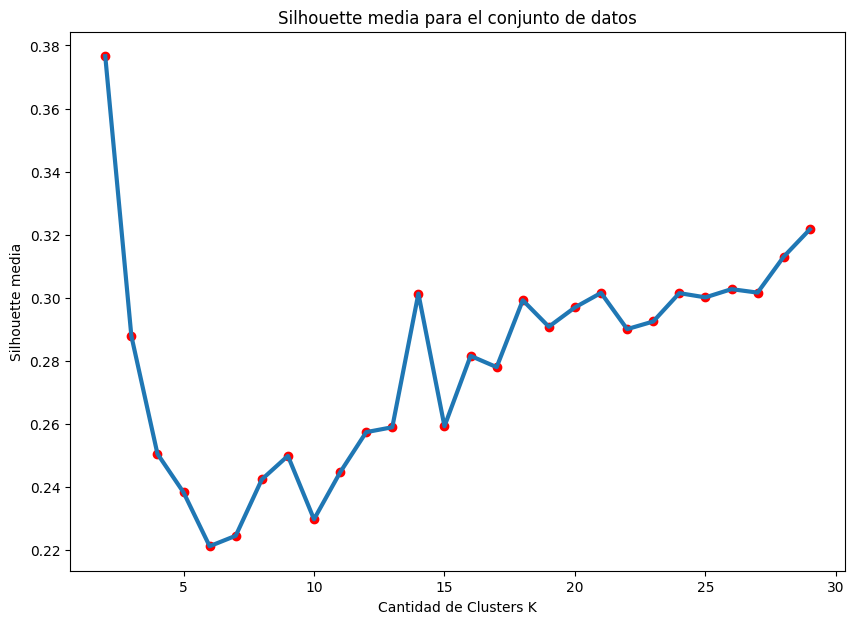

In [ ]:
sil_list = []

for k in K_list:
    km = KMeans(n_clusters=k, random_state=0) #  # Crear modelo para k específico
    km = km.fit(feature_mtx)

    etiquetas = km.labels_

    valor_medio_sil = silhouette_score(feature_mtx, etiquetas)
    sil_list.append(valor_medio_sil) # Guardar el valor de silhouette

plt.figure(figsize = (10,7))
plt.plot(K_list, sil_list, lw=3)
plt.scatter(K_list, sil_list, c='r')
plt.xlabel('Cantidad de Clusters K')
plt.ylabel('Silhouette media')
plt.title('Silhouette media para el conjunto de datos')

plt.show()

Observando los promedios de silueta para cada K se refuerza que k=14 o k =3 podría ser una cantidad óptima. Igual los valores promedios son muy bajo. Seleccionamos 3 grupos para poder interpretarlos.

In [ ]:
n_clusters = 3
clusterer = KMeans(n_clusters=n_clusters, random_state=0)
cluster_labels = clusterer.fit_predict(feature_mtx)


Para n_clusters = 3 El puntaje de silueta promedio es : 0.2879383403257327


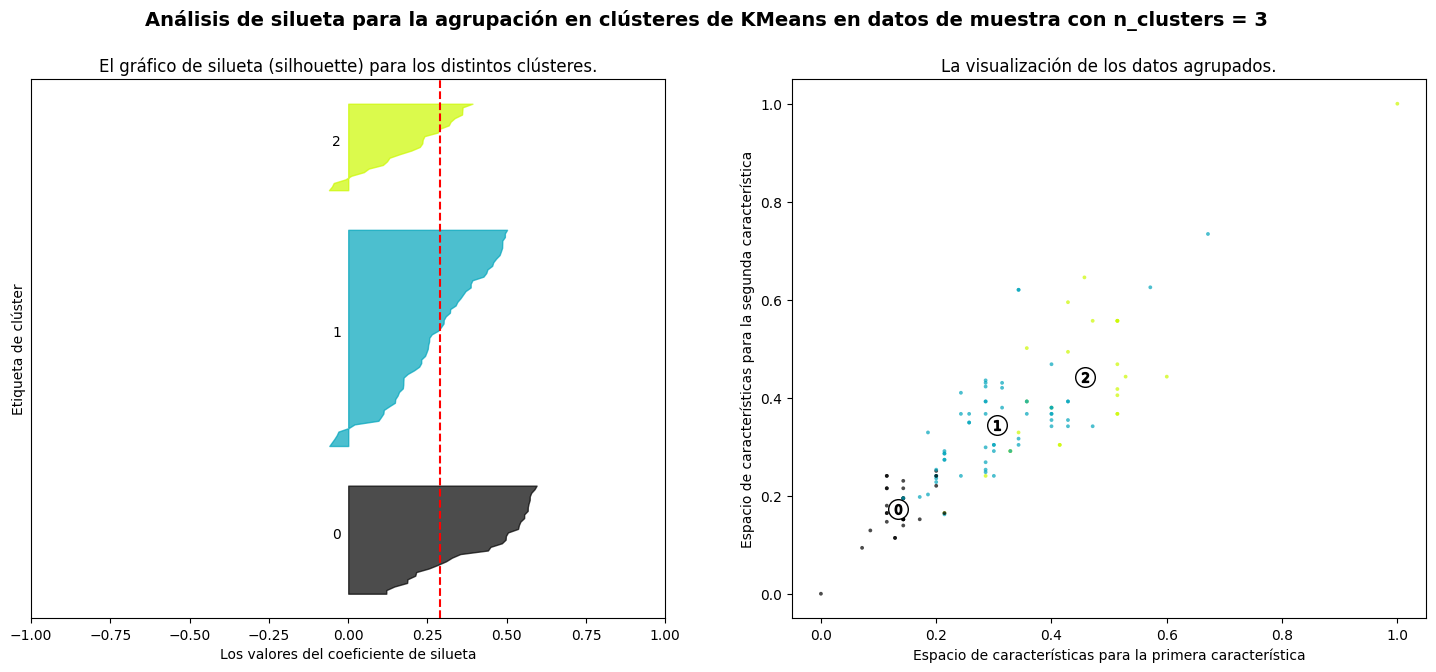

In [ ]:
silhouette_avg = silhouette_score(feature_mtx, cluster_labels)
print(
        "Para n_clusters =",
        n_clusters,
        "El puntaje de silueta promedio es :",
        silhouette_avg,
    )

# Calcular las puntuaciones de silueta para cada muestra
sample_silhouette_values = silhouette_samples(feature_mtx, cluster_labels)


# Crear una subparcela con 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

# La primera subtrama es la gráfica de silueta.
# El coeficiente de silueta puede variar entre -1 y 1, pero en este ejemplo todos los valores están dentro de [-0.1, 1].
ax1.set_xlim([-1, 1])

## El valor (n_clusters+1)*10 se utiliza para insertar un espacio en blanco entre los gráficos de silueta de los grupos individuales, para delimitarlos claramente.
#ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])
y_lower = 10
for i in range(n_clusters):
  # Agregar las puntuaciones de silueta de las muestras pertenecientes al grupo i y ordenarlas
  ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

  ith_cluster_silhouette_values.sort()

  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i

  color = cm.nipy_spectral(float(i) / n_clusters)
  ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
  # Etiqueta las parcelas de silueta con sus números de grupo en el medio
  ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
  # Calcular el nuevo y_lower para el siguiente gráfico
  y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("El gráfico de silueta (silhouette) para los distintos clústeres.")
ax1.set_xlabel("Los valores del coeficiente de silueta")
ax1.set_ylabel("Etiqueta de clúster")
# La línea vertical para la puntuación de silueta promedio de todos los valores
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])
#ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2da gráfica que muestra los grupos reales formados
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
ax2.scatter(
    feature_mtx[:, 0], feature_mtx[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)

    # Etiquetado de los clústeres
centers = clusterer.cluster_centers_

ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

for i, c in enumerate(centers):
  ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

ax2.set_title("La visualización de los datos agrupados.")
ax2.set_xlabel("Espacio de características para la primera característica")
ax2.set_ylabel("Espacio de características para la segunda característica")

plt.suptitle(
        "Análisis de silueta para la agrupación en clústeres de KMeans en datos de muestra con n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [ ]:
selec_df['cluster_'] = cluster_labels # Asiginar cluster a datos

/tmp/ipython-input-36-2484002596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selec_df['cluster_'] = cluster_labels # Asiginar cluster a datos


In [ ]:
selec_df.head() # Mostrar


,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,cluster_
0,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,0
1,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,1
2,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,1
3,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,0
4,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,1


In [ ]:
selec_df['cluster_'].value_counts() # Ver proporciones

,count
cluster_,
1,61
0,31
2,25


**Interpretar resultados**

In [ ]:
agg_cars = selec_df.groupby(['cluster_'])
agg_cars.mean()

,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg
cluster_,,,,,,,,
0,1.938710,123.032258,100.777419,67.777419,173.106452,2.636677,14.003226,28.709677
1,3.136066,190.950820,106.734426,71.062295,188.386885,3.380754,17.927869,23.439344
2,4.212000,229.920000,116.892000,75.732000,204.204000,4.038040,22.256000,20.080000


* Grupo 0: Autos compactos y eficientes. Con un consumo de combustible casi alto (mpg) y poca potencia (horsepow). Probablemente autos urbanos, hatchbacks, compactos.
* Grupo 1: Autos medianos, equilibrados. Con buen consumo de combustible y buena potencia. Pueden ser sedanes, autos familiares.
* Grupo 2: Autos grandes y potentes. Con bajo consumo de combustible, alta potencia.

/tmp/ipython-input-40-2673208712.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset.horsepow, subset.mpg,  c=color, label='cluster'+str(label),alpha=0.5)


Text(0, 0.5, 'mpg')

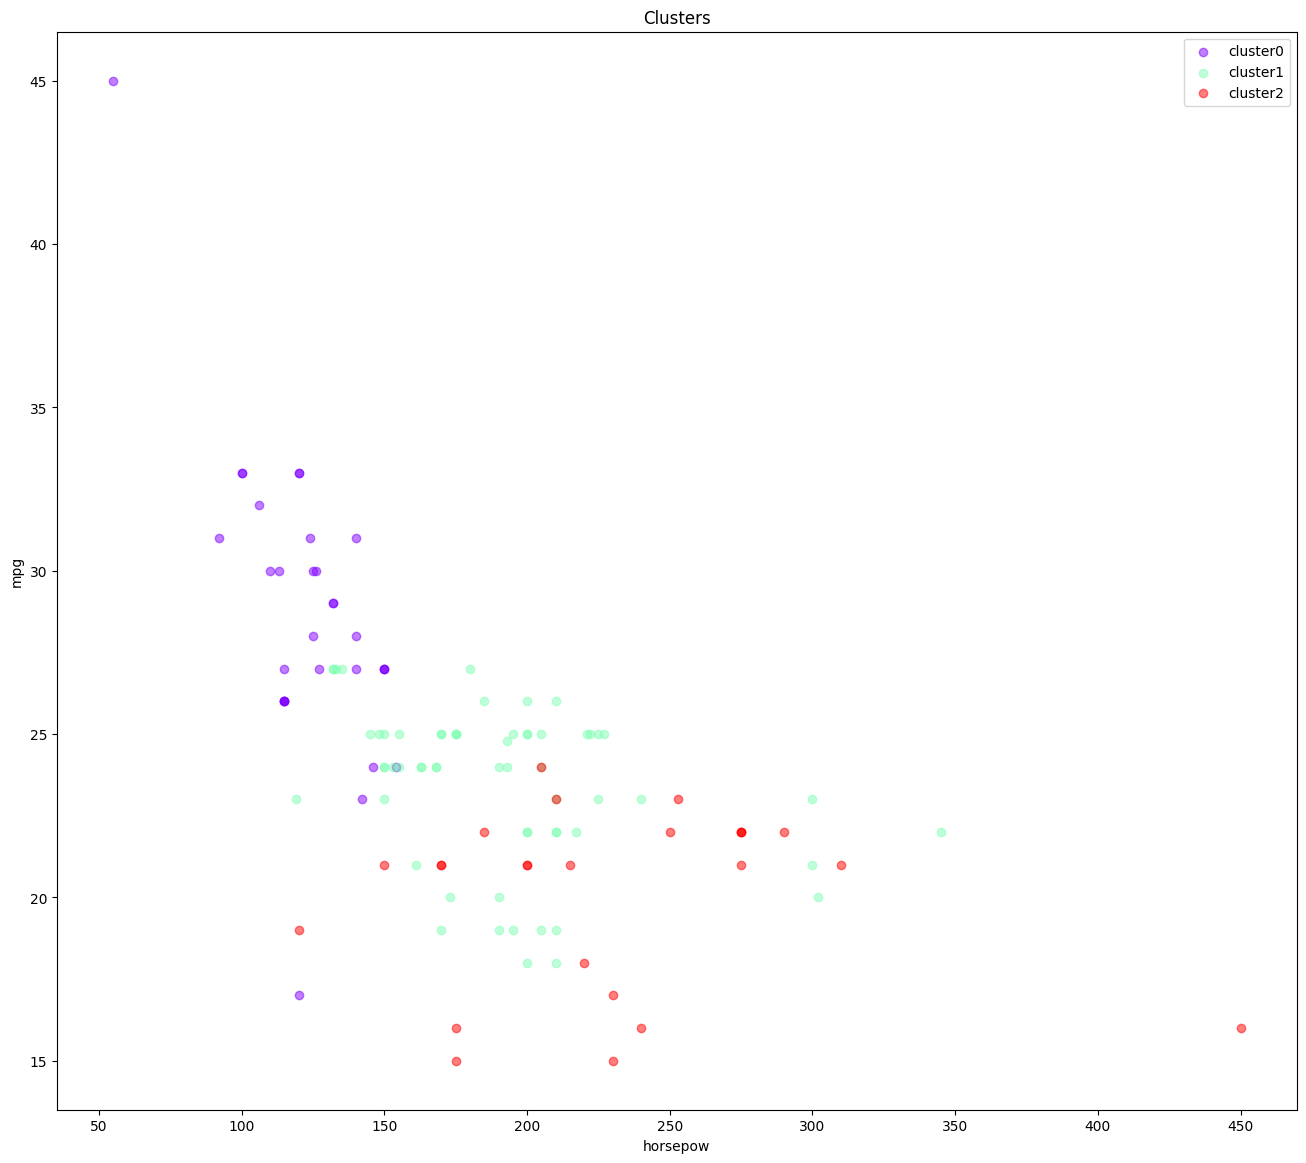

In [ ]:
import matplotlib.cm as cm
n_clusters = max(clusterer.labels_)+1
colors = cm.rainbow(np.linspace(0, 1, n_clusters))
cluster_labels = list(range(0, n_clusters))

# Create a figure of size 6 inches by 4 inches.
plt.figure(figsize=(16,14))

for color, label in zip(colors, cluster_labels):
  subset = selec_df[selec_df.cluster_ == label]
  plt.scatter(subset.horsepow, subset.mpg,  c=color, label='cluster'+str(label),alpha=0.5)
#    plt.scatter(subset.horsepow, subset.mpg)
plt.legend()
plt.title('Clusters')
plt.xlabel('horsepow')
plt.ylabel('mpg')

### Análisis de Componentes Principales: para reducir dimensionalidad y visualizar grupos


In [ ]:
selec_df.iloc[:,:-1].head()

,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg
0,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0
1,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0
2,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0
3,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0
4,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0


El proceso de PCA identifica las direcciones con mayor varianza. Como la varianza de una variable se mide en sus mismas unidades elevadas al cuadrado, si antes de calcular las componentes no se estandarizan todas las variables para que tengan media cero y desviación estándar de uno, aquellas variables cuya escala sea mayor dominarán al resto. De ahí que sea recomendable estandarizar siempre los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler
x = selec_df.iloc[:,:-1].values
x = StandardScaler().fit_transform(x) # normalizing the features

In [ ]:
x.shape

(117, 8)

In [ ]:
np.mean(x),np.std(x)



(np.float64(-3.112420103222661e-16), np.float64(1.0))

In [ ]:
# Crear Objeto PCA
pca = PCA() # Crear componentes principales

# Entrenar y transformar
componentes = pca.fit_transform(x)
print("Componentes principales:\n",componentes.shape)
print("Cantidad de componentes:",pca.n_components_)
print("Varianza explicada:", pca.explained_variance_ratio_)
print("Valores singulares:",pca.singular_values_)

Componentes principales:
 (117, 8)
Cantidad de componentes: 8
Varianza explicada: [0.68066424 0.1453097  0.07846722 0.03462569 0.02129208 0.01590993
 0.01375979 0.00997135]
Valores singulares: [25.24087414 11.66232755  8.57002413  5.69294662  4.46423444  3.85897611
  3.58875498  3.05502636]


Tanto la proporción de varianza explicada, como la proporción de varianza explicada acumulada, son dos valores de gran utilidad a la hora de decidir el número de componentes principales a utilizar en los análisis posteriores. Si se calculan todas las componentes principales de un set de datos, entonces, aunque transformada, se está almacenando toda la información presente en los datos originales. El sumatorio de la proporción de varianza explicada acumulada de todas las componentes es siempre 1.

In [ ]:
cumsum = np.cumsum(pca.explained_variance_ratio_) # Calcular varianza acumulada
print("Varianza acumulada:",cumsum)
d = np.argmax(cumsum >= 0.95) + 1 # Determinar la cantidad de componentes óptimos bajo umbral seleccionado
print("Cantidad de componentes que explican más 95% de varianza:", d, "componentes")

Varianza acumulada: [0.68066424 0.82597394 0.90444116 0.93906684 0.96035893 0.97626886
 0.99002865 1.        ]
Cantidad de componentes que explican más 95% de varianza: 5 componentes


In [ ]:
print("Varianza explicada por dos componentes:", np.cumsum(pca.explained_variance_ratio_[:2])[1]) # componentes[:,:2]


Varianza explicada por dos componentes: 0.8259739433758644


In [ ]:
selec_df[['PC1','PC2']]= componentes[:,:2] # Sumar componentes principales a datos

/tmp/ipython-input-48-349082806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selec_df[['PC1','PC2']]= componentes[:,:2] # Sumar componentes principales a datos
/tmp/ipython-input-48-349082806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selec_df[['PC1','PC2']]= componentes[:,:2] # Sumar componentes principales a datos


In [ ]:
selec_df.head() # Mostrar

,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,cluster_,PC1,PC2
0,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,0,-2.901097,-0.040295
1,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,1,0.341060,-0.258022
2,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,1,1.382249,0.224322
3,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,0,-1.924824,0.147707
4,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,1,1.082377,0.251049


<Axes: xlabel='PC1', ylabel='PC2'>

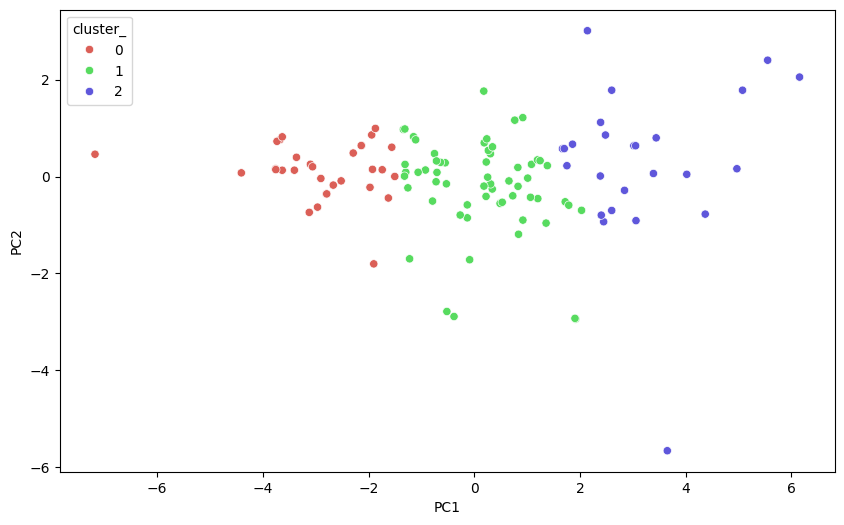

In [ ]:
import seaborn as sns

# Visualizar k-meadia con PCA
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="cluster_",
    palette=sns.color_palette("hls", 3),
    data=selec_df,
    legend="full",

)

Recordando la interpretación de clustering:
* 0	: Compactos / Económicos
* 1	: Familiares / Sedanes medianos
* 2	: Grandes / Potentes

**Interpretación de componentes**

Cada componente principal se obtiene por combinación lineal de las variables originales. Se pueden entender como nuevas variables obtenidas al combinar de una determinada forma las variables originales.

Los loadings son los que definen las componente. Los loadings pueden interpretarse como el peso/importancia que tiene cada variable en cada componente y, por lo tanto, ayudan a conocer que tipo de información recoge cada una de las componentes.

In [ ]:
# Se convierte  el array a dataframe para añadir nombres a los ejes.
components = pca.components_
pd.DataFrame(
    data    = components,
    columns = selec_df.iloc[:,:-3].columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7','PC8']
)

,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg
PC1,0.361105,0.300693,0.323016,0.365396,0.339893,0.399561,0.370259,-0.359256
PC2,-0.390568,-0.545021,0.549171,0.154774,0.413940,-0.006488,0.039740,0.227809
PC3,-0.268420,-0.397123,-0.050776,-0.231558,-0.403329,0.223124,0.519018,-0.481880
PC4,-0.018613,-0.251844,-0.329625,0.866808,-0.257291,-0.092178,0.021867,0.032342
PC5,-0.092497,0.317673,0.148402,0.018822,-0.286482,-0.032944,0.608015,0.644446
PC6,-0.112054,-0.084181,-0.340086,-0.046592,0.095095,0.846546,-0.154296,0.336210
PC7,0.691643,-0.409254,0.341144,-0.082349,-0.397294,0.125859,-0.144399,0.190912
PC8,0.381028,-0.340460,-0.478309,-0.168075,0.485073,-0.220140,0.420869,0.144872


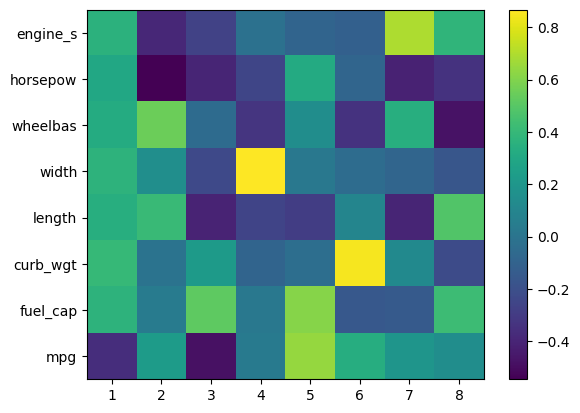

In [ ]:
plt.imshow(components.T, cmap='viridis', aspect='auto')
plt.yticks(range(len(selec_df.iloc[:,:-3].columns)), selec_df.iloc[:,:-3].columns)
plt.xticks(range(len(selec_df.iloc[:,:-3].columns)), np.arange(components.shape[0])+1)
plt.grid(False)
plt.colorbar()

Analizar con detalle el vector de loadings que forma cada componente puede ayudar a interpretar qué tipo de información recoge cada una de ellas. Por ejemplo, la primera componente es el resultado de la siguiente combinación lineal de las variables originales:

In [ ]:
# PC1 = 0.361105 * engine_s + 0.300693 * horsepow + 0.323016 * wheelbas + 0.365396 * width + 0.339893 * length + 0.399561 * curb_wgt + 0.370259 * fuel_cap - 0.359256 *  mpg

Dado a que tranformamos los datos

In [ ]:
x[0] # Muestra 1

array([-1.18851919, -0.70760105, -0.76427293, -1.10660259, -1.11075197,
       -1.15208399, -1.2208532 ,  0.88524147])

In [ ]:
engine_s = -1.18851919
horsepow =  -0.70760105
wheelbas =	-0.76427293
width = -1.10660259
length =	-1.11075197
curb_wgt = -1.15208399
fuel_cap = -1.2208532
mpg = 	0.88524147

# Calculamos el PC1
PC1 = 0.361105 * engine_s + 0.300693 * horsepow + 0.323016 * wheelbas + 0.365396 * width + 0.339893 * length + 0.399561 * curb_wgt + 0.370259 * fuel_cap - 0.359256 *  mpg
print("Valor de pc1 para muestra 1: ",PC1)

Valor de pc1 para muestra 1:  -2.9010962943578398


* **PC1**: Los pesos asignados en la primera componente a las variables seleccionadas son aproximadamente iguales entre ellos y superiores al asignado a *mpg*. El signo negativo en mpg (-0.359) indica que la eficiencia de combustible va en sentido opuesto al resto. PC1 puede representar el tamaño general del vehículo.

* **PC2**: Es ortogonal a PC1 (independiente) y captura la segunda mayor fuente de variación.
Está compuesta por: horsepow (-0.545) y engine_s (-0.390) en negativo. wheelbas (0.549) y length (0.414) en positivo. PC2 separa vehículos con dimensiones largas pero motores pequeños vs vehículos más compactos pero potentes.

Retomando la gráfica anterior

<Axes: xlabel='PC1', ylabel='PC2'>

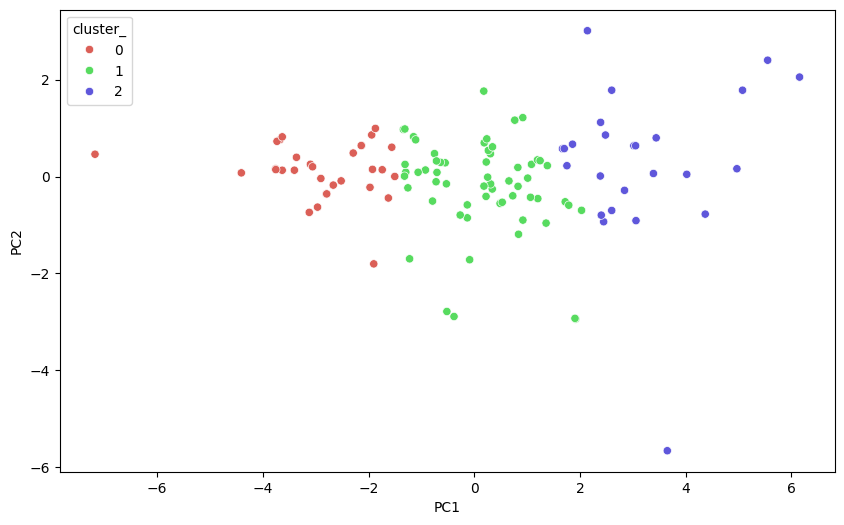

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="cluster_",
    palette=sns.color_palette("hls", 3),
    data=selec_df,
    legend="full",

)

* Valores altos de PC1 autos grandes, pesados, con motores potentes
* Valores bajos en PC2 , autos más cortos o compactos con más potencia relativa.

**Observaciones**
* Se aplicó k-means y se determinó que el K óptimos era k=3. Es conveniente analizar para k=14 y contemplar otros tipos de algoritmos para validar los grupos identificados.
* PCA se aplicó sobre 8 características numéricas que fueron escaladas. A través de dos componentes principales se logro representar más del 80% de varianza de los datos analizados.
* Relacionando PCA y K-medias se identifica claramente autos pesados con motores potentes y autos compactos con potencia relativa.
* Para ayudar mejor a los fabricantes a
identificar grupos de vehículos más distintivos, probar nuevos algoritmos como basados en conectividad y densidad, codificar variables categóricas, detectar valores atípicos.